##### Анализ лояльности пользователей Яндекс Афиши
- Автор: Анастасия Остроумова
- Дата: 05.12.2025

### 0.1 Цели и задачи проекта

**Цель:** провести исследовательский анализ лояльности пользователей Яндекс Афиши (июнь - октябрь 2024 года).
Результаты анализа помогут лучше понимать поведение пользователей, иметь представление, какие пользователи с большей вероятностью возвращаются на платформу и делают заказы повторно. 
В свою очередь это позволит:
* Быстро выявлять перспективных клиентов и предлагать им персонализированные условия.
* Точно настраивать рекламу на аудитории с высокой вероятностью возврата.
* Оптимизировать маркетинговые бюджеты.
* Повысить общий уровень удержания клиентов.
    
**Задачи:**
1. Загрузить данные и ознакомиться с их содержимым.  
2. Провести предобработку данных.
3. Создать профиль пользователя.
4. Провести исследовательский анализ данных:
    - Исследование признаков первого заказа и их связи с возвращением на платформу
    - Исследование поведения пользователей через показатели выручки и состава заказа
    - Исследование временных характеристик первого заказа и их влияния на повторные покупки
    - Корреляционный анализ количества покупок и признаков пользователя
5. Сформулировать выводы и рекомендации и рекомендации для заказчика.

### 0.2 Описание данных
* `user_id` — уникальный идентификатор пользователя, совершившего заказ;
* `device_type_canonical` — тип устройства, с которого был оформлен заказ ( mobile — мобильные устройства, desktop — стационарные);
* `order_id` — уникальный идентификатор заказа;
* `order_dt` — дата создания заказа (используйте данные created_dt_msk );
* `order_ts` — дата и время создания заказа (используйте данные created_ts_msk );
* `currency_code` — валюта оплаты;
* `revenue` — выручка от заказа;
* `tickets_count` — количество купленных билетов;
* `days_since_prev` — количество дней от предыдущей покупки пользователя, для пользователей с одной покупкой — значение пропущено;
* `event_id` — уникальный идентификатор мероприятия;
* `service_name` — название билетного оператора;
* `event_type_main` — основной тип мероприятия (театральная постановка, концерт и так далее);
* `region_name` — название региона, в котором прошло мероприятие;
* `city_name` — название города, в котором прошло мероприятие.

### 0.3 Содержимое проекта

1. Загрузка данных и знакомство с ними
2. Предобработка данных
3. Создание профиля пользователя
4. Исследовательский анализ данных
5. Итоговый вывод и рекомендации

---

## 1. Загрузка данных и знакомство с ними

In [1]:
!pip install sqlalchemy

Defaulting to user installation because normal site-packages is not writeable


In [2]:
!pip install psycopg2

Defaulting to user installation because normal site-packages is not writeable


In [3]:
# Импортируем библиотеки
import pandas as pd
from sqlalchemy import create_engine 
import numpy as np

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
!pip install phik
from phik import phik_matrix

Defaulting to user installation because normal site-packages is not writeable


In [4]:
# Подключаемся к базе данных
db_config = {'user': 'praktikum_student', # имя пользователя
             'pwd': 'Sdf4$2;d-d30pp', # пароль
             'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
             'port': 6432, # порт подключения
             'db': 'data-analyst-afisha' # название базы данных
             } 
connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db'],
) 

# Создаем соединение
engine = create_engine(connection_string) 

In [5]:
# Извлекаем результаты запроса
query = '''
SELECT user_id
     , device_type_canonical
     , order_id
     , created_dt_msk AS order_dt
     , created_ts_msk AS order_ts
     , currency_code
     , revenue
     , tickets_count
     , created_dt_msk::date - LAG(created_dt_msk::date) OVER(PARTITION BY user_id ORDER BY created_dt_msk) AS days_since_prev
     , event_id
     , event_name_code AS event_name
     , event_type_main
     , service_name
     , region_name
     , city_name
FROM afisha.purchases p
INNER JOIN afisha.events e USING(event_id)
INNER JOIN afisha.city c USING(city_id)
INNER JOIN afisha.regions r USING(region_id)
WHERE device_type_canonical IN ('desktop', 'mobile') 
      AND event_type_main != 'фильм'
ORDER BY user_id;
'''

df = pd.read_sql_query(query, con=engine)
df_copy = df.copy()

Познакомимся с данными получившегося датасета

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

Датасет содержит 15 столбцов и 290 611 строк. Кроме столбца `days_since_prev` пропусков нет, но в данном столбце это ожидаемо, так как предыдущего заказа может и не быть.

In [7]:
# Выводим первые строки датафрейма на экран
df.head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name
0,0002849b70a3ce2,mobile,4359165,2024-08-20,2024-08-20 16:08:03,rub,1521.94,4,NaN,169230,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,театр,Край билетов,Каменевский регион,Глиногорск
1,0005ca5e93f2cf4,mobile,7965605,2024-07-23,2024-07-23 18:36:24,rub,289.45,2,NaN,237325,40efeb04-81b7-4135-b41f-708ff00cc64c,выставки,Мой билет,Каменевский регион,Глиногорск
2,0005ca5e93f2cf4,mobile,7292370,2024-10-06,2024-10-06 13:56:02,rub,1258.57,4,75.0,578454,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,другое,За билетом!,Каменевский регион,Глиногорск
3,000898990054619,mobile,1139875,2024-07-13,2024-07-13 19:40:48,rub,8.49,2,NaN,387271,2f638715-8844-466c-b43f-378a627c419f,другое,Лови билет!,Североярская область,Озёрск
4,000898990054619,mobile,972400,2024-10-04,2024-10-04 22:33:15,rub,1390.41,3,83.0,509453,10d805d3-9809-4d8a-834e-225b7d03f95d,стендап,Билеты без проблем,Озернинский край,Родниковецк


После первичного анализа данных можно сделать следующие выводы:
названия столбцов оформлены корректно, может потребоваться оптимизация данных и приведение типов для некоторых столбцов.

---


### Промежуточный вывод

Таблица с данными о покупке билетов на мероприятия содержит *15 столбцов* и *290 611 строк*

* Названия столбцов оформлены корректно.
* Данные содержат числовые, текстовые значения и даты и хранятся в типах данных object, int64, datetime64 и float64.
* Пропуски содержатся только в столбце `days_since_prev` что ожидаемо, так как у некоторых пользователей может быть только один заказ.
* В качестве дальнейшей предобработки можно будет выполнить следующие шаги:
  - Значения в столбце `days_since_prev` можно привести к Int64, так как там достаточно целочисленного типа.
  - Для столбца `tickets_count` можно уменьшить размерность данных.
  - Есть две категории валют: рубли и тенге, нужно будет обработать столбец, чтобы привести значения столбца с выручкой к одной валюте.
  - Остальные столбцы не требуют преобразований.
* Следует проверить столбцы на наличие значений, заменяющих пропуски.
* Данные в столбце `revenue` следует проверить на наличие аномальных значений.

Таким образом, данные имеют хорошее качество и достаточный объем для анализа. Основное внимание при предобработке следует уделить приведению типов данных и приведению столбца с прибылью к единой валюте.

---

## 2. Предобработка данных

Приведем значения в столбце `revenue` к рублям. Для этого загрузим датасет с актуальным курсом обмена валют. Значения в рублях представлено для 100 тенге.

In [8]:
df_rates = pd.read_csv('final_tickets_tenge_df.csv')

In [9]:
df_rates.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


In [10]:
df_rates.head()

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt


In [11]:
df_rates['data'] = pd.to_datetime(df_rates['data'])

In [12]:
# Рассчитаем курс за 1 KZT для удобства:
df_rates['kzt_to_rub_rate'] = df_rates['curs'] / 100

# Выберем только нужные столбцы для объединения
df_rates_simple = df_rates[['data', 'kzt_to_rub_rate']]

In [13]:
# Объединяем основную таблицу с таблицей курсов по дате
df = pd.merge(
    df,
    df_rates_simple,
    left_on='order_dt',
    right_on='data',
    how='left' # Используем left join, чтобы не потерять строки с RUB
)

In [14]:
# Используем np.where() для условного присвоения:
df['revenue_rub'] = np.where(
    # Условие:
    df['currency_code'] == 'kzt',
    # Если True (тенге): revenue * rate
    df['revenue'] * df['kzt_to_rub_rate'],
    # Если False (рубли): revenue
    df['revenue']
)

# Удалим вспомогательный столбец с курсом
df = df.drop(columns=['kzt_to_rub_rate', 'data'])
df['revenue_rub'] = df['revenue_rub'].round(2)

In [15]:
df.sort_values(by='currency_code').head()

,user_id,device_type_canonical,order_id,order_dt,order_ts,currency_code,revenue,tickets_count,days_since_prev,event_id,event_name,event_type_main,service_name,region_name,city_name,revenue_rub
83697,3ee7dc2e115847f,desktop,6883934,2024-06-11,2024-06-11 12:47:24,kzt,10338.19,3,0.0,536825,76af4f88-c554-4e9e-9df4-1cc8aeec8959,концерты,Мой билет,Шанырский регион,Широковка,2056.56
175995,8f4e4d4a4ae404e,mobile,1874387,2024-09-07,2024-09-07 11:11:06,kzt,1849.41,1,1.0,533803,0686ac7b-6f3e-4177-bb73-16b54acd1223,концерты,Мой билет,Шанырский регион,Широковка,343.97
175997,8f4e4d4a4ae404e,desktop,6468625,2024-09-17,2024-09-17 13:02:51,kzt,414.43,3,9.0,559937,83de0409-c9db-4f3f-816e-20af0e779a54,другое,Билеты без проблем,Верхоречная область,Серебрянка,78.79
175998,8f4e4d4a4ae404e,mobile,6468422,2024-09-26,2024-09-26 20:49:47,kzt,82.19,1,9.0,559582,524f434e-0381-4f47-9688-7c4e41961b65,другое,Билеты без проблем,Верхоречная область,Серебрянка,15.83
175999,8f4e4d4a4ae404e,mobile,880325,2024-09-30,2024-09-30 09:08:39,kzt,1773.07,1,4.0,538781,9b9ebaea-efbc-4507-9630-d5910c9b121f,концерты,Билеты без проблем,Шанырский регион,Широковка,343.52


Преобразование данных выполнено успешно. Теперь в столбце `revenue_rub` содержится выручка с заказа в рублях.

---

Проверим датасет на пропущенные значения.

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int64         
 8   days_since_prev        268678 non-null  float64       
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

Пропуски содержатся только в столбце `days_since_prev`. Их мы обрабатывать не будем, так как в данном случае их количество обосновано и говорит о том, что у пользователя был только один заказ.

Обработаем столбцы с числовыми данными, сократим их размерность, приведем типы.

In [17]:
# Оптимизируем целочисленный тип данных в поле tickets_count
df['tickets_count'] = pd.to_numeric(df['tickets_count'], downcast='integer')

# Приведем значения в поле days_since_prev к целочисленному типу
df['days_since_prev'] = df['days_since_prev'].astype('Int64')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290611 entries, 0 to 290610
Data columns (total 16 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   user_id                290611 non-null  object        
 1   device_type_canonical  290611 non-null  object        
 2   order_id               290611 non-null  int64         
 3   order_dt               290611 non-null  datetime64[ns]
 4   order_ts               290611 non-null  datetime64[ns]
 5   currency_code          290611 non-null  object        
 6   revenue                290611 non-null  float64       
 7   tickets_count          290611 non-null  int8          
 8   days_since_prev        268678 non-null  Int64         
 9   event_id               290611 non-null  int64         
 10  event_name             290611 non-null  object        
 11  event_type_main        290611 non-null  object        
 12  service_name           290611 non-null  obje

Столбцы, требующие преобразования типов преобразованы, выделены данные о часе, месяце и дне недели покупки. 

---

Изучим значения в ключевых столбцах. Проверим, какие категории указаны в столбцах с номинальными данными. 

In [19]:
# Проверяем количество уникальных значения в столбцe event_type_main
# df['event_type_main'].nunique()
df['event_type_main'].unique()

array(['театр', 'выставки', 'другое', 'стендап', 'концерты', 'спорт',
       'ёлки'], dtype=object)

Всего в данных есть 7 типов мероприятий, один из которых включает в себя разные типы - другое.

In [20]:
# Проверяем количество уникальных значения в столбцe service_name
# df['service_name'].nunique()
df['service_name'].sort_values().unique()

array(['Crazy ticket!', 'Show_ticket', 'Билет по телефону',
       'Билеты без проблем', 'Билеты в интернете', 'Билеты в руки',
       'Быстробилет', 'Быстрый кассир', 'Весь в билетах', 'Восьмёрка',
       'Вперёд!', 'Выступления.ру', 'Городской дом культуры',
       'Дом культуры', 'Дырокол', 'За билетом!', 'Зе Бест!', 'КарандашРУ',
       'Кино билет', 'Край билетов', 'Лимоны', 'Лови билет!',
       'Лучшие билеты', 'Мир касс', 'Мой билет', 'Облачко', 'Прачечная',
       'Радио ticket', 'Реестр', 'Росбилет', 'Тебе билет!', 'Телебилет',
       'Тех билет', 'Цвет и билет', 'Шоу начинается!', 'Яблоко'],
      dtype=object)

Всего есть 36 билетных операторов, выделяющихся значений в столбце нет.

In [21]:
df['city_name'].nunique()
# df['city_name'].sort_values().unique()

352

In [22]:
df['region_name'].nunique()
# df['region_name'].sort_values().unique()

81

В столбцах с городом и регионом скрытых пропусков нет. 

В целом, в номинальных столбцах отклонений не обнаружено, замена значений не требуется.

---

Проверим столбцы `revenue_rub` и `tickets_count` на выбросы и отклоняющиеся значения.

In [23]:
print(df[['revenue_rub', 'tickets_count']].describe())

         revenue_rub  tickets_count
count  290611.000000  290611.000000
mean      555.571989       2.754311
std       875.498170       1.170620
min       -90.760000       1.000000
25%       113.970000       2.000000
50%       351.140000       3.000000
75%       802.050000       4.000000
max     81174.540000      57.000000


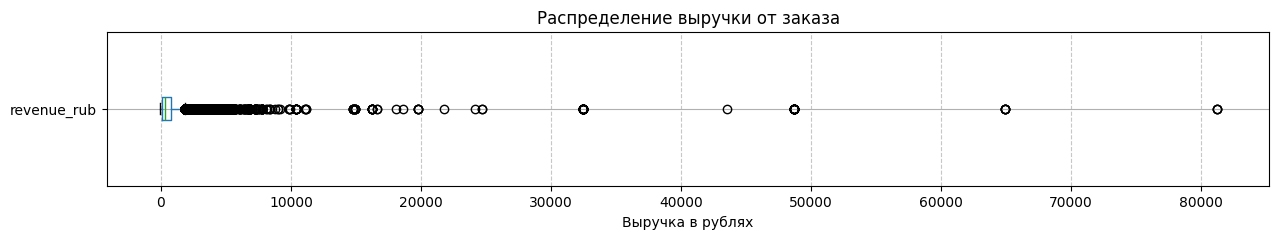

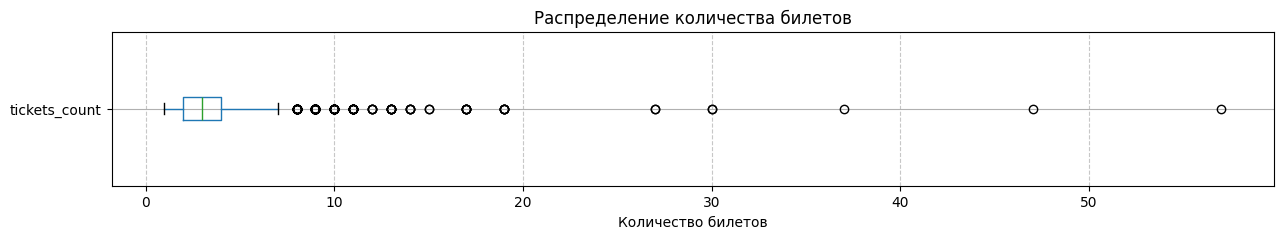

In [24]:
# 1. Горизонтальная диаграмма размаха для revenue_rub
plt.figure(figsize=(15, 2))

df.boxplot(column='revenue_rub', vert=False)
plt.title('Распределение выручки от заказа')
plt.xlabel('Выручка в рублях')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 2. Горизонтальная диаграмма размаха для tickets_count
plt.figure(figsize=(15, 2))

df.boxplot(column='tickets_count', vert=False)
plt.title('Распределение количества билетов')
plt.xlabel('Количество билетов')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

В обоих столбцах есть значительное количество отклонений - особенно это заметно в поле с выручкой. При среднем значении равном 555,6 рублей стандартное отклонение составляет целых 875,5 рублей. Отфильтруем значения по 99 перцентилю.

In [25]:
# 1. Находим значение 99-го перцентиля для revenue_rub
threshold_99_revenue = df['revenue_rub'].quantile(0.99)

print(f"Значение 99-го перцентиля (порог): {threshold_99_revenue:.2f} RUB")

Значение 99-го перцентиля (порог): 2628.42 RUB


In [26]:
# 1. Находим значение 99-го перцентиля для tickets_count
threshold_99_tickets = df['tickets_count'].quantile(0.99)

print(f"Значение 99-го перцентиля (порог): {threshold_99_tickets} штук")

Значение 99-го перцентиля (порог): 6.0 штук


In [27]:
# 2. Фильтруем DataFrame
# фильтруем данные по выручке по 99 персентилю
df_filtered = df[df['revenue_rub'] <= threshold_99_revenue].copy()

# так как выручка с заказа не может быть отрицательной и нулевой, исключим и эти значения
df_filtered = df_filtered[df_filtered['revenue_rub'] > 0]

# фильтруем данные по количеству билетов по 99 персентилю
df_filtered = df_filtered[df_filtered['tickets_count'] <= threshold_99_tickets]

# Сравнение размеров
# Проверим сколько удалено строк датасета
a, b = len(df), len(df_filtered)
print(" Было строк в исходном датасете", a,
      '\n', "Осталось строк в датасете после обработки", b,
      '\n', "Удалено строк в датасете после обработки", a-b,
      '\n', "Процент потерь", round((a-b)/a*100, 2))

 Было строк в исходном датасете 290611 
 Осталось строк в датасете после обработки 281705 
 Удалено строк в датасете после обработки 8906 
 Процент потерь 3.06


Аномальные значения были отфильтрованы, осталось 281 705 строк, построим новые диаграммы размаха.

In [28]:
print(df_filtered[['revenue_rub', 'tickets_count']].describe())

         revenue_rub  tickets_count
count  281705.000000  281705.000000
mean      528.641073       2.739706
std       511.630948       1.137586
min         0.020000       1.000000
25%       122.610000       2.000000
50%       358.080000       3.000000
75%       797.640000       3.000000
max      2628.420000       6.000000


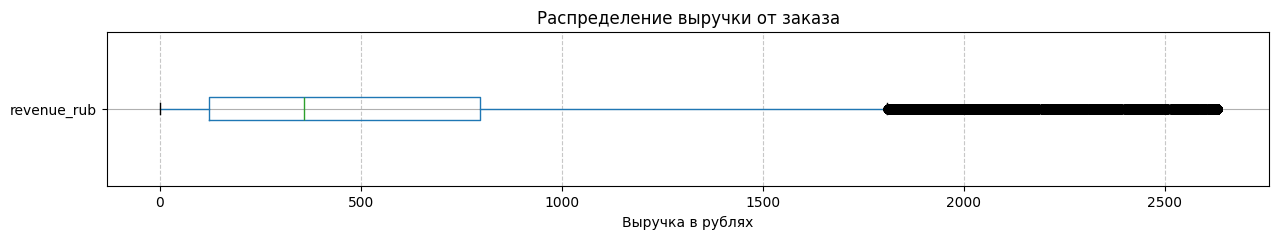

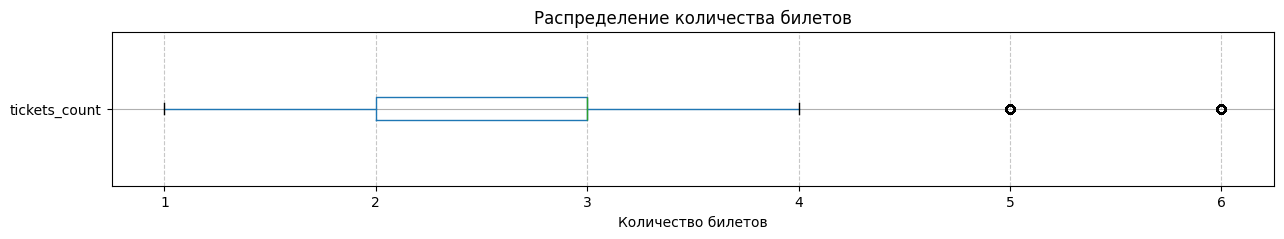

In [29]:
# 1. Горизонтальная диаграмма размаха для revenue_rub
plt.figure(figsize=(15, 2))

df_filtered.boxplot(column='revenue_rub', vert=False)
plt.title('Распределение выручки от заказа')
plt.xlabel('Выручка в рублях')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 2. Горизонтальная диаграмма размаха для tickets_count
plt.figure(figsize=(15, 2))

df_filtered.boxplot(column='tickets_count', vert=False)
plt.title('Распределение количества билетов')
plt.xlabel('Количество билетов')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

После обработки диаграммы размаха дают более наглядное представление о распределении данных. Интересно, что медиана и 75-й перцентиль для количества билетов совпадают - это означает, что значительная часть значений сосредоточена на одном уровне и разброс в верхней части выборки минимален.

---

### 2.1. Промежуточный вывод

1. **Обработка пропусков**
    * Пропуски присутствуют только в столбце days_since_prev и соответствуют первой покупке пользователя.
    * Пропуски не заполнялись.
    * Тип столбца преобразован в Int64, что позволяет хранить NA в числовом формате.

2. **Оптимизация типов данных**
    * Столбец tickets_count приведён к целочисленному типу с уменьшением разрядности.
    * Столбец days_since_prev приведён к целочисленному формату.

3. **Потери данных** в результате исключения выбросов по 99 персентилю для столбцов `revenue`, `tickets_count` и исключению отрицательных и нулевых значений для `revenue`. 
    * Исходный объём данных: 290 611 строк.
    * После обработки: 281 705 строк.
    * Удалено: 8 906 строк (3.05%).
    * Доля потерь данных невелика.

4. **Анализ числовых признаков**
    `revenue_rub`
    * Средний чек - ~528 руб., медианный ниже (358 руб.), что говорит о правостороннем распределении.
    * Типичный диапазон оплат - 122-797 руб.
    * Минимум - 0.02 руб., максимум - 2628.42 руб.
    * Разброс значений остаётся высоким.

    `tickets_count`
    * В среднем покупают 2-3 билета.
    * Медиана и 75-й перцентиль равны 3 - большинство пользователей приобретают ровно три билета.
    * Значения лежат в диапазоне от 1 до 6 билетов.

5. **Изучены значения в ключевых номинальных столбцах.** Отклонений не обнаружено.

---

## 3. Создание профиля пользователя

### 3.1. Профиль пользователя

In [30]:
df_filtered = df_filtered.sort_values(['user_id', 'order_dt'])

In [31]:
# Группировка по пользователю
user_profile = df_filtered.groupby('user_id').agg(
    first_order_dt  = ('order_dt', 'min'),
    last_order_dt   = ('order_dt', 'max'),
    first_device      = ('device_type_canonical', 'first'),
    first_region      = ('region_name', 'first'),
    first_service     = ('service_name', 'first'),
    first_event_type  = ('event_type_main', 'first'),
    total_orders      = ('order_id', 'count'),
    avg_revenue_rub   = ('revenue_rub', 'mean'),
    avg_tickets_count = ('tickets_count', 'mean'),
    avg_days_between  = ('days_since_prev', 'mean'),
).reset_index()

# Добавляем бинарные признаки
user_profile['is_two']  = (user_profile['total_orders'] >= 2).astype(int)
user_profile['is_five'] = (user_profile['total_orders'] >= 5).astype(int)

# Округление
user_profile['avg_revenue_rub'] = user_profile['avg_revenue_rub'].round(2)
user_profile['avg_tickets_count']     = user_profile['avg_tickets_count'].round(2)
user_profile['avg_days_between'] = user_profile['avg_days_between'].round(2)

In [32]:
user_profile.head()

,user_id,first_order_dt,last_order_dt,first_device,first_region,first_service,first_event_type,total_orders,avg_revenue_rub,avg_tickets_count,avg_days_between,is_two,is_five
0,0002849b70a3ce2,2024-08-20,2024-08-20,mobile,Каменевский регион,Край билетов,театр,1,1521.94,4.00,<NA>,0,0
1,0005ca5e93f2cf4,2024-07-23,2024-10-06,mobile,Каменевский регион,Мой билет,выставки,2,774.01,3.00,75.0,1,0
2,000898990054619,2024-07-13,2024-10-23,mobile,Североярская область,Лови билет!,другое,3,767.21,2.67,51.0,1,0
3,00096d1f542ab2b,2024-08-15,2024-08-15,desktop,Каменевский регион,Край билетов,театр,1,917.83,4.00,<NA>,0,0
4,000a55a418c128c,2024-09-29,2024-10-15,mobile,Поленовский край,Лучшие билеты,театр,2,61.31,1.50,16.0,1,0


Профиль пользователя построен. Далее проанализируем полученные данные.

---

### 3.2. Расчёты по профилям пользователей и Статистические показатели

In [33]:
# Общее число пользователей
total_users = user_profile.shape[0]

# Средняя выручка с одного заказа (по всем заказам в исходном df_filtered)
avg_revenue_per_order = df_filtered['revenue_rub'].mean()

# Доля пользователей, совершивших 2+ заказов
share_two = user_profile['is_two'].mean()

# Доля пользователей, совершивших 5+ заказов
share_five = user_profile['is_five'].mean()

print("Общее число пользователей:", total_users)
print("Средняя выручка с одного заказа:", round(avg_revenue_per_order, 2))
print("Доля пользователей с 2+ заказами:", round(share_two * 100, 2), "%")
print("Доля пользователей с 5+ заказами:", round(share_five * 100, 2), "%")

Общее число пользователей: 21693
Средняя выручка с одного заказа: 528.64
Доля пользователей с 2+ заказами: 61.66 %
Доля пользователей с 5+ заказами: 28.87 %


In [34]:
# Статистические показатели

print("\nСтатистика по общему числу заказов:")
display(user_profile['total_orders'].describe())

print("\nСтатистика по среднему числу билетов:")
display(user_profile['avg_tickets_count'].describe())

print("\nСтатистика по среднему количеству дней между покупками:")
display(user_profile['avg_days_between'].describe())


Статистика по общему числу заказов:


count    21693.000000
mean        12.985986
std        119.680177
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max       9974.000000
Name: total_orders, dtype: float64


Статистика по среднему числу билетов:


count    21693.000000
mean         2.742030
std          0.903874
min          1.000000
25%          2.000000
50%          2.750000
75%          3.080000
max          6.000000
Name: avg_tickets_count, dtype: float64


Статистика по среднему количеству дней между покупками:


count      13446.0
mean     15.904461
std      22.351109
min            0.0
25%            1.0
50%            8.0
75%           20.5
max          148.0
Name: avg_days_between, dtype: Float64

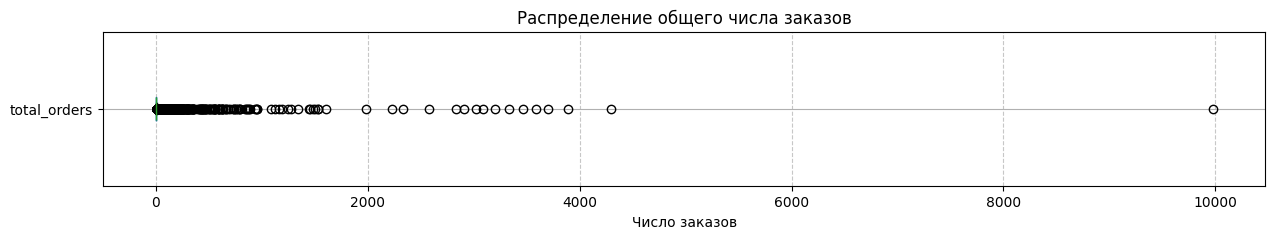

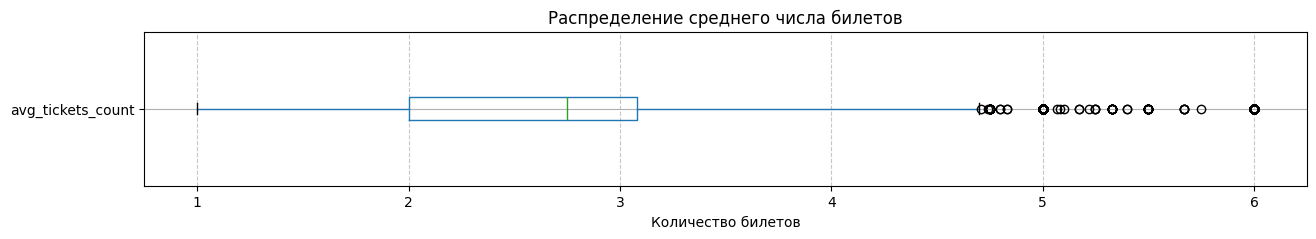

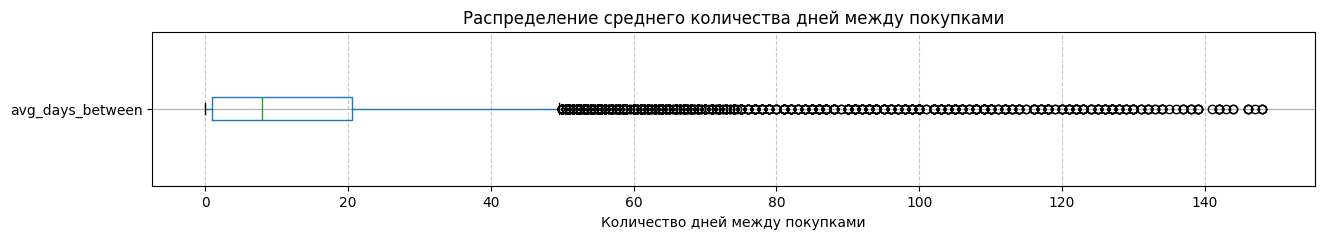

In [35]:
# 1. Горизонтальная диаграмма размаха для total_orders
plt.figure(figsize=(15, 2))

user_profile.boxplot(column='total_orders', vert=False)
plt.title('Распределение общего числа заказов')
plt.xlabel('Число заказов')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 2. Горизонтальная диаграмма размаха для avg_tickets
plt.figure(figsize=(15, 2))

user_profile.boxplot(column='avg_tickets_count', vert=False)
plt.title('Распределение среднего числа билетов')
plt.xlabel('Количество билетов')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 2. Горизонтальная диаграмма размаха для avg_days_between
plt.figure(figsize=(15, 2))

user_profile.boxplot(column='avg_days_between', vert=False)
plt.title('Распределение среднего количества дней между покупками')
plt.xlabel('Количество дней между покупками')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

#### Оценка данных

**Объём данных**
Число пользователей - 21 693.
Это достаточно большая выборка, чтобы делать устойчивые выводы.

1. **Общее число заказов**
    * Медиана - 2 заказа
    * 75-й перцентиль - 5 заказов
    * Но максимум - 9974 заказа
    * Стандартное отклонение огромно - 119.7

Это явная аномалия. У типичного пользователя максимум несколько заказов, а почти 10 000 - это, вероятно, технический партнёр, бот или ошибочная запись.
Такое значение искажает среднее (среднее намного больше медианы).

2. **Среднее число билетов**
    * Среднее - 2.74
    * Медиана - 2.75
    * Максимум - 6

Здесь аномалий нет. Покупка 6 билетов - нормальное бытовое поведение. Распределение выглядит естественно.

3. **Среднее время между покупками**
    * Медиана - 8 дней
    * Среднее - 15.9 дней — почти вдвое больше медианы. Это указывает на длинный правый хвост: есть пользователи, которые делают заказы с очень большими интервалами.
    * Максимальный интервал — 148 дней, что является нормальным пользовательским поведением (например, человек покупает билеты раз в несколько месяцев).

Распределение не содержит аномалий: интервалы редких покупок повышают среднее, но не являются ошибочными значениями.

Данные стоит отфильтровать. Оптимально - по 99-му перцентилю, чтобы убрать явно ошибочные/технические записи, но сохранить живых пользователей.

In [36]:
# Находим значение 99-го перцентиля
threshold_99 = user_profile['total_orders'].quantile(0.99)

# Создадим копию таблицы с пользователями
user_profile_copy = user_profile.copy()

# Фильтруем данные
user_profile_copy = user_profile_copy[user_profile_copy['total_orders'] <= threshold_99]

# Сравнение размеров
# Проверим сколько удалено строк датасета
a, b = len(user_profile), len(user_profile_copy)
print(" Было строк в исходном датасете", a,
      '\n', "Осталось строк в датасете после обработки", b,
      '\n', "Удалено строк в датасете после обработки", a-b,
      '\n', "Процент потерь", round((a-b)/a*100, 2))

 Было строк в исходном датасете 21693 
 Осталось строк в датасете после обработки 21476 
 Удалено строк в датасете после обработки 217 
 Процент потерь 1.0


In [37]:
user_profile_copy['total_orders'].describe()

count    21476.000000
mean         6.403381
std         13.979047
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max        150.000000
Name: total_orders, dtype: float64

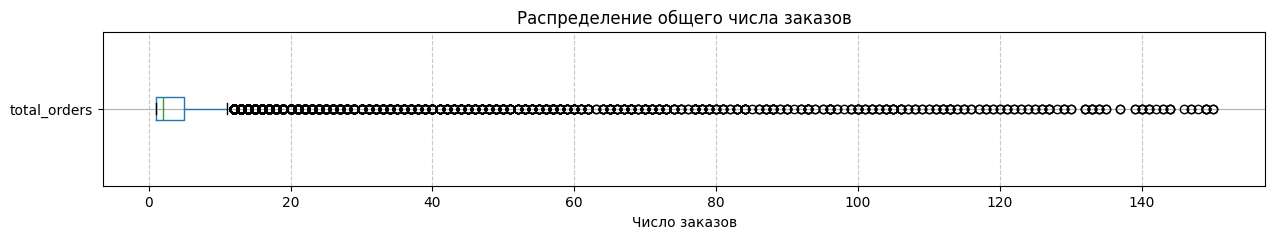

In [38]:
# 1. Горизонтальная диаграмма размаха для total_orders
plt.figure(figsize=(15, 2))

user_profile_copy.boxplot(column='total_orders', vert=False)
plt.title('Распределение общего числа заказов')
plt.xlabel('Число заказов')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

#### Выводы после удаления аномальных значений

После удаления пользователей с экстремально высоким числом заказов:
* Удалено 217 строк (1% выборки), что является допустимой потерей данных.
* Фильтрация значительно улучшила статистику:
    * Среднее число заказов снизилось с ~13.99 до 6.40, что теперь гораздо ближе к реальному распределению.
    * Медиана осталась прежней - 2 заказа, что подтверждает: удалённые значения находились в "хвосте" и не отражали типичного поведения.
    * Максимальное число заказов стало 150 вместо 9974 — это более реалистичная верхняя граница.
* Распределение по-прежнему остаётся асимметричным (правосторонний хвост), но аномальные всплески устранены.

Финальный набор данных выглядит более корректным для анализа пользовательской активности, а ключевые статистики теперь лучше отражают поведение большинства пользователей.

## 4. Исследовательский анализ данных

### 4.1. Исследование признаков первого заказа и их связи с возвращением на платформу

#### 4.1.2. Сегментация пользователей

In [39]:
# Сегменты по жанру первого мероприятия (first_event_type)
# количество пользователей
seg_event = user_profile_copy.groupby('first_event_type')['user_id'].nunique().reset_index(name='users_count').sort_values('users_count', ascending=False)

# доля от общего числа пользователей
total_users = user_profile_copy['user_id'].nunique()
seg_event['users_share'] = seg_event['users_count'] / total_users

# Сортировка по убыванию доли
seg_event = seg_event.sort_values('users_count', ascending=False)

# Красивый вывод
seg_event.style.format({'users_share': '{:.2%}'}).background_gradient(
    subset=['users_share'], cmap='YlGnBu'
).set_caption('Сегменты по жанру первого мероприятия')

,first_event_type,users_count,users_share
2,концерты,9608,44.74%
1,другое,5208,24.25%
5,театр,4265,19.86%
4,стендап,1125,5.24%
3,спорт,767,3.57%
0,выставки,408,1.90%
6,ёлки,95,0.44%


Распределение пользователей по сегментам неравномерное. Явно выделяются выраженные "точки входа" - категории, через которые большинство людей делает свою первую покупку.

Ключевые наблюдения:
* Концерты — крупнейший сегмент, в него попадает почти половина всех пользователей (44,7%). Это основная точка входа.
* Второй по величине сегмент - другое (24,3%), который также привлекает значимую часть аудитории.
* Театр занимает третье место (19,9%), что делает его ещё одной заметной группой.
* Остальные категории - стендап, спорт, выставки, ёлки - имеют значительно меньшие доли (от ~5% до <1%) и не являются основными точками входа.

**Итог:**

Распределение ярко асимметричное: основная масса новых пользователей приходит через концерты, а также в меньшей степени - через другие мероприятия и театр. Остальные сегменты выполняют скорее нишевую роль.

In [40]:
# Сегменты по типу устройства, с которого совершена первая покупка (first_device)
# количество пользователей
seg_device = user_profile_copy.groupby('first_device')['user_id'].nunique().reset_index(name='users_count').sort_values('users_count', ascending=False)

# доля от общего числа пользователей
total_users = user_profile_copy['user_id'].nunique()
seg_device['users_share'] = seg_device['users_count'] / total_users

# Сортировка по убыванию медианы
seg_device = seg_device.sort_values('users_count', ascending=False)

# Красивый вывод
seg_device.style.format({'users_share': '{:.2%}'}).background_gradient(
    subset=['users_share'], cmap='YlGnBu'
).set_caption('Сегменты по типу устройства, с которого совершена первая покупка')

,first_device,users_count,users_share
1,mobile,17779,82.79%
0,desktop,3697,17.21%


Распределение по устройствам резко неравномерное - существует ярко выраженная точка входа.

* 82,8% пользователей совершают свой первый заказ с мобильных устройств. Это доминирующий сегмент, через который приходит подавляющее большинство аудитории.
* Лишь 17,2% пользователей впервые покупают с десктопа.

**Итог:**

Большинство пользователей впервые взаимодействуют с сервисом через мобильные устройства, что делает мобильный канал ключевым для привлечения новой аудитории.

In [41]:
# Сегменты по региону проведения мероприятия из первого заказа (first_region)
# количество пользователей
seg_region = user_profile_copy.groupby('first_region')['user_id'].nunique().reset_index(name='users_count').sort_values('users_count', ascending=False)

# доля от общего числа пользователей
total_users = user_profile_copy['user_id'].nunique()
seg_region['users_share'] = seg_region['users_count'] / total_users

# Сортировка по убыванию медианы
seg_region = seg_region.sort_values('users_count', ascending=False)

# Красивый вывод
seg_region.style.format({'users_share': '{:.2%}'}).background_gradient(
    subset=['users_share'], cmap='YlGnBu'
).set_caption('Сегменты по региону проведения мероприятия из первого заказа')

,first_region,users_count,users_share
23,Каменевский регион,6974,32.47%
60,Североярская область,3779,17.60%
77,Широковская область,1240,5.77%
45,Озернинский край,676,3.15%
41,Малиновоярский округ,524,2.44%
76,Шанырский регион,464,2.16%
57,Светополянский округ,462,2.15%
74,Травяная область,458,2.13%
52,Речиновская область,444,2.07%
78,Яблоневская область,409,1.90%


###### Распределение пользователей по регионам резко неравномерное и демонстрирует одну крупную "точку входа" и несколько выраженных регионов-лидеров.

* Доминирующий сегмент:
    * Каменевский регион - 32.47% всех пользователей. Это крупнейший источник первых заказов: каждый третий пользователь начинает именно здесь.

* Крупные, но существенно меньшие сегменты:
    * Североярская область - 17.60%
    * Широковская область - 5.77%
Уже после второго места наблюдается резкое падение: доля всех остальных регионов - менее 6% каждый, а у большинства - ниже 2%.

* Хвост распределения:
    * Очень большое количество регионов имеет долю меньше 0.5%.

**Итог:**

Распределение по регионам сильно смещено:
первые заказы пользователей концентрируются в нескольких крупных регионах, в особенности - в Каменевском. Остальные регионы дают значительно меньший поток новых пользователей и образуют длинный "хвост" с минимальными долями.

Таким образом, точки входа явно выражены, а распределение нельзя считать равномерным.

In [42]:
# Сегменты по билетному оператору, продавшему билеты на первый заказ (first_service)
# количество пользователей
seg_service = user_profile_copy.groupby('first_service')['user_id'].nunique().reset_index(name='users_count').sort_values('users_count', ascending=False)

# доля от общего числа пользователей
total_users = user_profile_copy['user_id'].nunique()
seg_service['users_share'] = seg_service['users_count'] / total_users

# Красивый вывод
seg_service.style.format({'users_share': '{:.2%}'}).background_gradient(
    subset=['users_share'], cmap='YlGnBu'
).set_caption('Сегменты по билетному оператору, продавшему билеты на первый заказ')

,first_service,users_count,users_share
3,Билеты без проблем,4948,23.04%
22,Мой билет,3003,13.98%
19,Лови билет!,2814,13.10%
4,Билеты в руки,2541,11.83%
23,Облачко,2193,10.21%
7,Весь в билетах,1295,6.03%
20,Лучшие билеты,1184,5.51%
24,Прачечная,575,2.68%
17,Край билетов,464,2.16%
12,Дом культуры,351,1.63%


Распределение пользователей по билетным операторам также неравномерное и показывает выраженные "точки входа" - несколько крупных операторов, через которых проходит большая часть первых покупок.

* Крупные сегменты (доминирующие операторы). Заметно выделяются 5 операторов, на которых приходится почти 72% всех пользователей:
    * Билеты без проблем - 23,04%
    * Мой билет - 13.98%
    * Лови билет! - 13.10%
    * Билеты в руки - 11.83%
    * Облачко - 10.21%

Каждый из них привлекает значительные доли первых заказов, что делает их ключевыми каналами входа пользователей.

* Средние сегменты. Дальнейшие операторы имеют доли от 1% до ~6%, например:
    * Весь в билетах - 6.03%
    * Лучшие билеты - 5.51%

Они формируют заметную, но не доминирующую часть трафика.

* Длинный хвост
    * Более 20 операторов дают менее 1% каждый.
    * Некоторые — менее 0.1%.

Это говорит о высокой фрагментации рынка в хвосте распределения: небольшие и нишевые продавцы почти не участвуют в первичном привлечении пользователей.

**Общие выводы**

Распределение сильно перекошено: пять крупнейших операторов обеспечивают львиную долю первых заказов, а остальные формируют длинный хвост с очень низкой долей каждого сегмента.

Следовательно, "точки входа" выражены чётко, и пользовательский трафик концентрируется вокруг нескольких основных билетных операторов.

#### Общий вывод по сегментации пользователей

Анализ профилей пользователей показывает, что распределение по ключевым признакам первого заказа неравномерное. На рынке существуют выраженные точки входа - сегменты, которые привлекают значительно больше пользователей, чем остальные.

**1. Тип первого мероприятия**  
Наиболее значимый сегмент - `концерты`, на которые приходится почти половина всех первых покупок `(около 45%)`. Далее идут категории "другое" и театр. Оставшиеся типы событий формируют небольшие доли. Распределение сильно перекошено в сторону концертов, которые являются главным каналом первичного привлечения пользователей.

**2. Устройство первого заказа**  
Большинство пользователей совершают свою первую покупку с `мобильного устройства` - `более 80%`. Десктопы используются значительно реже, `менее чем в 20%` случаев. Это указывает на чёткую доминацию мобильного трафика и важность оптимизации первого опыта именно в мобильном канале.

**3. Регион первого события**  
Распределение по регионам также неравномерное: два крупнейших региона дают около половины всех первых заказов. Далее следует длинный хвост из десятков регионов, каждый из которых формирует малую долю. Это говорит о высокой концентрации аудитории в нескольких ключевых локациях и широкой, но слабо представленной географической базе.

**4. Билетный оператор первого заказа**  
Топ-5 операторов обеспечивают более `70%` всех первых покупок. Лидером является `Билеты без проблем`, далее следуют `Мой билет`, `Лови билет!`, `Билеты в руки` и `Облачко`. Остальные операторы дают небольшие доли, часто `менее 1%`. Рынок первого контакта пользователей с билетным сервисом концентрирован вокруг нескольких крупных игроков.

**Общий вывод**

По всем рассмотренным признакам распределения имеют выраженные лидирующие сегменты. Несколько категорий, устройств, регионов и операторов дают основную массу новых пользователей, тогда как остальные сегменты образуют длинный хвост. Это подтверждает существование чётких точек входа в сервис, что важно учитывать при анализе поведения пользователей, планировании маркетинга и работе с удержанием.

---

#### 4.1.2. Анализ возвратов пользователей

In [43]:
# Функция для расчёта долей
def calc_segment_share(df, segment_col, top_threshold=15, top_n=10):
    seg = (
        df.groupby(segment_col)
          .agg(
              users_total=('user_id', 'count'),
              users_2plus=('is_two', 'sum')  # здесь теперь просто суммируем is_two
          ).reset_index().sort_values(by='users_total', ascending=False)
    )

    seg['share_2plus'] = seg['users_2plus'] / seg['users_total']

    # Ограничение топ-10 при большом количестве сегментов
    if seg.shape[0] > top_threshold:
        seg = seg.nlargest(top_n, 'users_total')

    return seg

In [44]:
# Функция для визуализации
def plot_segment_share(seg, segment_col):
    plot_df = seg.copy()

    if len(seg) > 15:
        plot_df = seg.head(10)

    plot_df = plot_df.sort_values('share_2plus', ascending=False)

    plt.figure(figsize=(10, 6))
    plt.barh(plot_df[segment_col], plot_df['share_2plus'], color='skyblue')
    plt.gca().invert_yaxis()
    plt.xlabel('Доля пользователей с 2+ заказами')
    plt.title(f'Доля пользователей с ≥2 заказами по сегменту: {segment_col}')
    plt.tight_layout()
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

In [45]:
# По типу первого мероприятия
seg_event_2plus = calc_segment_share(user_profile_copy, 'first_event_type').sort_values('share_2plus', ascending=False)
seg_event_2plus.style.format({'share_2plus': '{:.2%}'}).background_gradient(
    subset=['share_2plus'], cmap='YlGnBu'
).set_caption('Доля пользователей с ≥2 заказами по типу мероприятия')

,first_event_type,users_total,users_2plus,share_2plus
0,выставки,408,260,63.73%
5,театр,4265,2710,63.54%
2,концерты,9608,5936,61.78%
4,стендап,1125,688,61.16%
1,другое,5208,3090,59.33%
6,ёлки,95,53,55.79%
3,спорт,767,422,55.02%


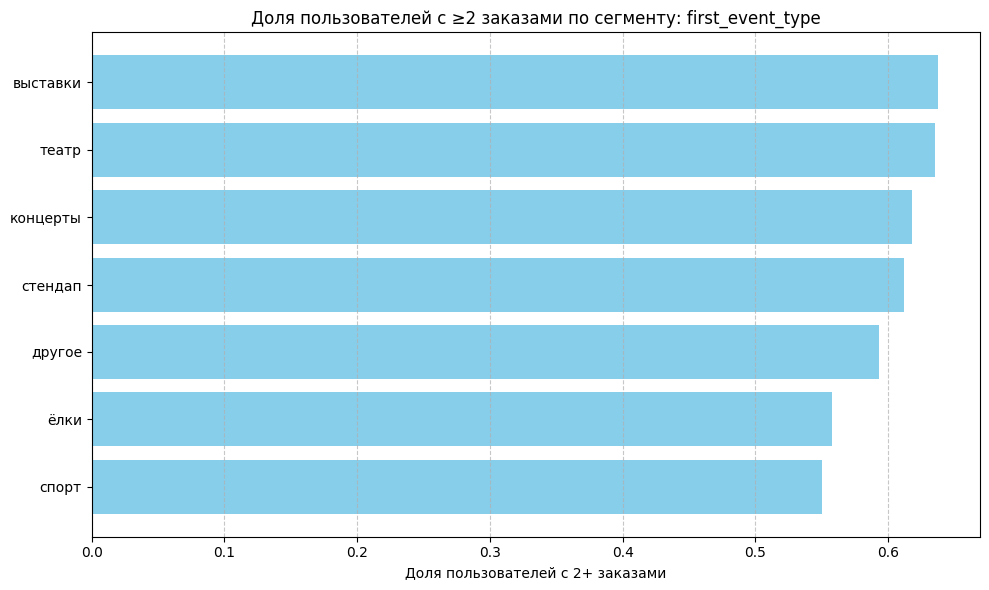

In [46]:
plot_segment_share(seg_event_2plus, 'first_event_type')

Распределение долей пользователей, совершивших два и более заказов, показывает умеренную вариативность по сегментам:

- Сегменты с **наиболее высокой долей возвратов** - *выставки* (63.73%) и *театр* (63.54%). Пользователи этих категорий чаще возвращаются за повторными покупками.
- **Крупнейший сегмент - концерты** - имеет высокую долю (61.78%), что подтверждает его стабильный уровень вовлечённости.
- **Самая низкая доля** повторных заказов у сегментов *ёлки* (55.79%) и *спорт* (55.02%). Их пользователи заметно реже совершают вторую покупку.

В целом, различия между сегментами не радикальны (примерно 55-64%), но некоторые сегменты демонстрируют более высокий потенциал повторных продаж - прежде всего выставки, театр и концерты.

In [47]:
# По типу устройства первого заказа
seg_device_2plus = calc_segment_share(user_profile_copy, 'first_device').sort_values('share_2plus', ascending=False)
seg_device_2plus.style.format({'share_2plus': '{:.2%}'}).background_gradient(
    subset=['share_2plus'], cmap='YlGnBu'
).set_caption('Доля пользователей с ≥2 заказами по устройству, используемому для совершения покупки')

,first_device,users_total,users_2plus,share_2plus
0,desktop,3697,2358,63.78%
1,mobile,17779,10801,60.75%


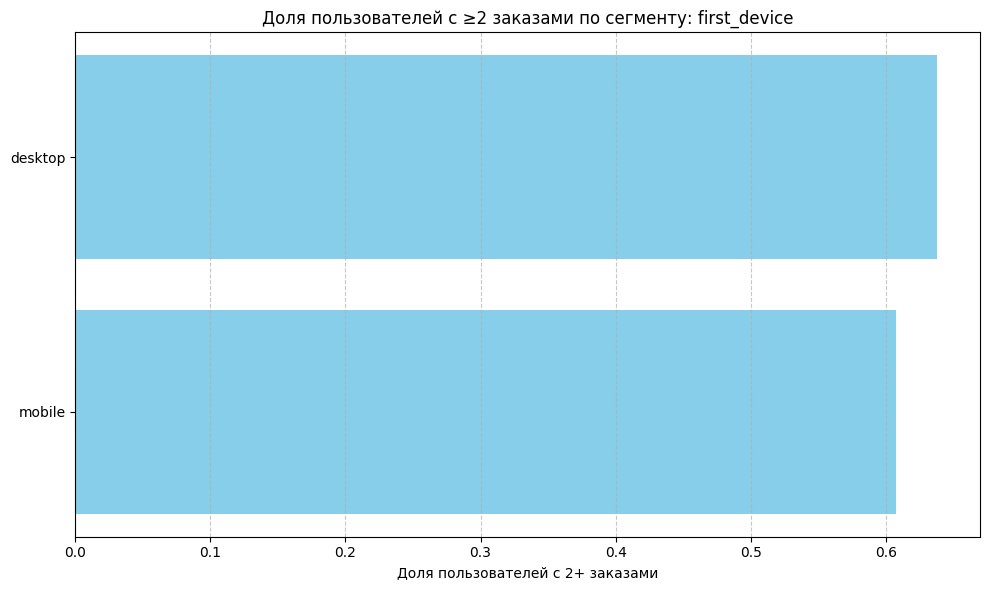

In [48]:
plot_segment_share(seg_device_2plus, 'first_device')

Анализ распределения показывает умеренные различия между сегментами:

- **Пользователи desktop** совершают повторные покупки чаще - **63.78%** из них имеют два и более заказов.
- **Пользователи mobile** возвращаются чуть реже - **60.75%**.

Разница около **3 процентных пунктов** указывает на то, что desktop-пользователи более "вовлечённые" или принимают решения о покупке более осознанно. Однако, учитывая огромный перекос в объёме сегментов (mobile - 82.8% всех пользователей), оба устройства формируют сопоставимо стабильную долю повторных заказов.

**Общий вывод:** тип устройства оказывает влияние, но не ключевое. Мобильные пользователи хотя и доминируют по объёму, но немного уступают desktop по уровню возврата.

In [49]:
# По региону первого заказа
seg_region_2plus = calc_segment_share(user_profile_copy, 'first_region').sort_values('share_2plus', ascending=False)
seg_region_2plus.style.format({'share_2plus': '{:.2%}'}).background_gradient(
    subset=['share_2plus'], cmap='YlGnBu'
).set_caption('Доля пользователей с ≥2 заказами по региону проведения мероприятия')

,first_region,users_total,users_2plus,share_2plus
76,Шанырский регион,464,322,69.40%
57,Светополянский округ,462,304,65.80%
77,Широковская область,1240,802,64.68%
60,Североярская область,3779,2419,64.01%
52,Речиновская область,444,283,63.74%
23,Каменевский регион,6974,4318,61.92%
74,Травяная область,458,281,61.35%
78,Яблоневская область,409,242,59.17%
41,Малиновоярский округ,524,291,55.53%
45,Озернинский край,676,372,55.03%


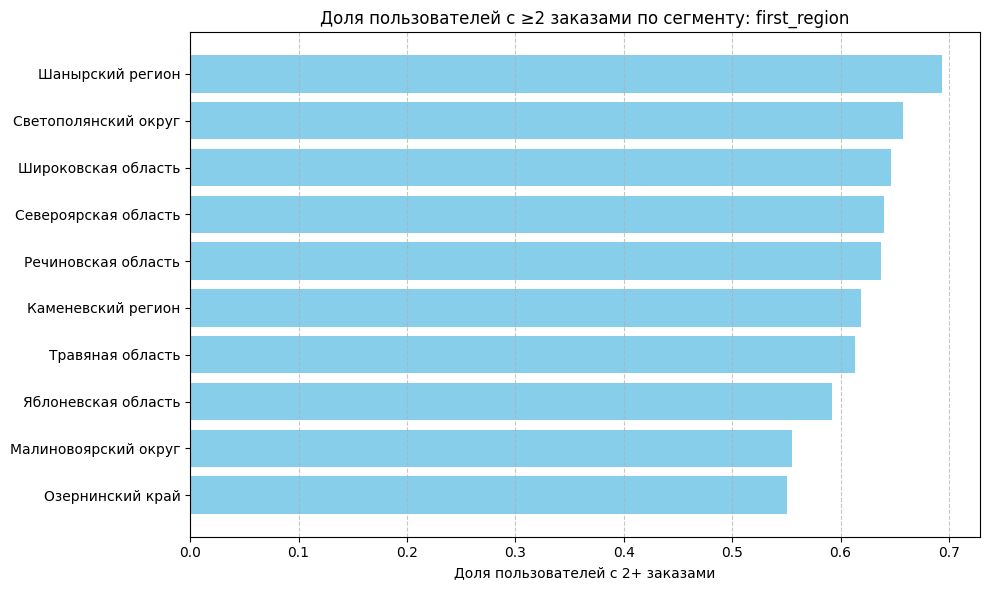

In [50]:
plot_segment_share(seg_region_2plus, 'first_region')

Топ-10 регионов по числу пользователей показывают заметный разброс в доле повторных заказов - **от ~55% до почти 70%**. Это означает, что регион проведения первого мероприятия влияет на вероятность возвращаемости пользователя.

**Ключевые наблюдения:**

- **Лидеры по доле повторных заказов:**
  - **Шанырский регион**
  - **Светополянский округ**
  - **Широковская область**
  - **Североярская область**
  - **Речиновская область**

  Эти регионы демонстрируют высокую вовлечённость: больше двух третей пользователей возвращаются.

- **Крупные регионы по объёму пользователей**:
  - **Каменевский регион**
  - **Североярская область**
  - **Широковская область**

  Они обеспечивают основной объём аудитории и удерживают высокие доли повторных заказов.

- **Регион с минимальной долей среди топ-10**:
  - **Озернинский край**
  - **Малиновоярский округ**

  Повторные покупки здесь заметно ниже среднего уровня.

**Общий вывод:**  
Регион первого посещённого мероприятия связан с вероятностью вернуться: некоторые территории демонстрируют повышенную вовлечённость, достигая почти 70% пользователей с повторными заказами.

In [51]:
# По билетному оператору первого заказа
seg_region_2plus = calc_segment_share(user_profile_copy, 'first_service').sort_values('share_2plus', ascending=False)
seg_region_2plus.style.format({'share_2plus': '{:.2%}'}).background_gradient(
    subset=['share_2plus'], cmap='YlGnBu'
).set_caption('Доля пользователей с ≥2 заказами по билетному оператору')

,first_service,users_total,users_2plus,share_2plus
17,Край билетов,464,305,65.73%
12,Дом культуры,351,225,64.10%
7,Весь в билетах,1295,816,63.01%
4,Билеты в руки,2541,1597,62.85%
24,Прачечная,575,356,61.91%
20,Лучшие билеты,1184,728,61.49%
19,Лови билет!,2814,1725,61.30%
23,Облачко,2193,1344,61.29%
22,Мой билет,3003,1826,60.81%
3,Билеты без проблем,4948,2952,59.66%


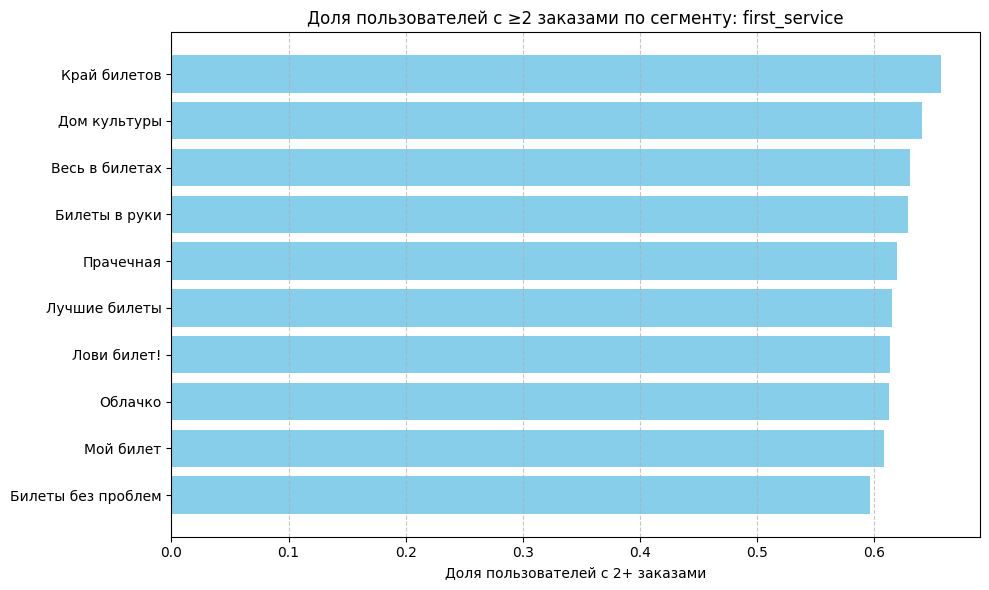

In [52]:
plot_segment_share(seg_region_2plus, 'first_service')

Топ-10 билетных операторов по числу пользователей демонстрируют довольно близкие значения доли повторных заказов - в диапазоне **от ~60% до 66%**. Это говорит о том, что оператор оказывает влияние, но эффект менее выражен, чем у типа события или региона.

**Ключевые наблюдения:**

- **Лидеры по доле повторных заказов:**
  - **Край билетов**
  - **Дом культуры**
  - **Весь в билетах**
  - **Билеты в руки**

  Эти операторы демонстрируют более высокую вовлечённость аудитории.

- **Крупные по объёму операторы:**
  - **Билеты без проблем**
  - **Мой билет**
  - **Лови билет!**
  - **Облачко**

  Несмотря на большой охват, их доля повторных заказов чуть ниже, ближе к 60%.

**Общий вывод:**  
Разница между билетными операторами по удержанию есть, но она умеренная. Все крупные игроки показывают долю повторных заказов около 60-62%. Однако отдельные более нишевые операторы демонстрируют повышенную лояльность (≈64-66%), что может отражать особенности сервиса, UX, цен или качества предложения.

#### Общий вывод по возвратам пользователей

Анализ доли пользователей, совершивших два и более заказа, по четырём сегментирующим признакам - *тип первого мероприятия*, *тип устройства*, *регион первого мероприятия* и *первый билетный оператор* - показывает устойчивые закономерности в поведении клиентов.

**1. Тип первого мероприятия**
Доли повторных заказов распределены достаточно равномерно - **от 55% до 64%**.  
Лучше всего возвращаются пользователи, начавшие путь с "выставок" и "театра", хуже — из сегментов "спорт" и "ёлки". Разница между категориями составляет около 8-9 п.п.  
**Вывод:** тип события влияет на возвратность, но умеренно.

**2. Тип устройства**
Разница между сегментами небольшая:  
- **desktop - 63.78%**  
- **mobile - 60.75%**  

Доля повторных заказов у пользователей с desktop немного выше, но в целом поведение схожее.  
**Вывод:** устройство почти не влияет на вероятность сделать повторный заказ.

**3. Регион проведения первого мероприятия**
Здесь разброс значительнее: от **~55% до почти 70%** среди крупных сегментов.  
Региональная структура спроса влияет на возвратность сильнее, чем тип события или устройство.  
**Вывод:** некоторые регионы обладают значительно более "лояльной" аудиторией.

**4. Билетный оператор первого заказа**
Значения также достаточно близки - **от ~60% до 66%** в топ-10 операторов.  
Лидеры по доле повторных заказов - "Край билетов" и "Дом культуры".  

**Общий вывод:**  
Различия между операторами есть, но оператор влияет меньше, чем регион.

---

#### 4.1.3. Проверка продуктовых гипотез

**Гипотеза 1.** Тип мероприятия влияет на вероятность возврата на Яндекс Афишу: пользователи, которые совершили первый заказ на спортивные мероприятия, совершают повторный заказ чаще, чем пользователи, оформившие свой первый заказ на концерты.

**Что показывают данные:**

- Доля пользователей с ≥2 заказами среди тех, кто начал со **спорта**: **55.02%**
- Доля пользователей с ≥2 заказами среди тех, кто начал с **концертов**: **61.78%**

**Вывод:**  
Полученные данные **не подтверждают гипотезу**.  
Наоборот, пользователи, которые впервые пришли на концерты, возвращаются **чаще**, чем те, кто начал со спортивных мероприятий - разница составляет почти **7 процентных пунктов**.

Следовательно, тип мероприятия действительно влияет на вероятность повторного заказа, но эффект противоположен заявленной гипотезе.

---

**Гипотеза 2.** В регионах, где больше всего пользователей посещают мероприятия, выше доля повторных заказов, чем в менее активных регионах.

**Что показывают данные:**

Топ-5 регионов по количеству пользователей:  
- Каменевский регион - **6 974 пользователей**
- Североярская область - **3 779 пользователей**
- Широковская область - **1 240 пользователей** 
- Озернинский край - **676 пользователей**
- Малиновоярский округ - **524 пользователей**

Топ регионов по доле повторных заказов:  
- Шанырский регион - **69.40%**  
- Светополянский округ - **65.80%**  
- Широковская область - **64.68%**  
- Североярская область - **64.01%**  
- Речиновская область - **63.74%**

Сравнение показывает, что:

- Среди регионов *с самым большим количеством пользователей* только два - **Североярская** и **Широковская области** - действительно входят в лидеры по доле повторных заказов.
- Самый крупный по числу пользователей регион (**Каменевский**) имеет долю повторных заказов **выше среднего**, но не максимальную.
- Несколько регионов, входящих в топ по доле повторных заказов, имеют относительно небольшие пользовательские базы.

**Общие выводы:**  
Гипотеза **частично подтверждается**, но не полностью.  
Активные по числу пользователей регионы действительно могут демонстрировать высокую долю повторных заказов, однако **это не универсальное правило**.  
Верхние позиции по повторным заказам занимают и регионы с гораздо меньшими объёмами пользователей.  

Следовательно, **размер региона по числу первых заказов сам по себе не гарантирует более высокой лояльности пользователей**.

---

### 4.2. Исследование поведения пользователей через показатели выручки и состава заказа

In [53]:
# Дополнительные таблицы по количеству заказов
one_order = user_profile_copy[user_profile_copy['is_two'] == 0]         # пользователи с 1 заказом
two_plus_orders = user_profile_copy[user_profile_copy['is_two'] == 1]   # пользователи с 2+ заказами
two_to_four_orders = user_profile_copy[
    (user_profile_copy['total_orders'] > 1) & (user_profile_copy['total_orders'] <= 4)
]                                                             # пользователи с 4-5 заказами
five_plus_orders = user_profile_copy[user_profile_copy['is_five'] == 1] # пользователи с 5+ заказами

####  4.2.1. Связь между средней выручкой сервиса с заказа и повторными заказами

In [54]:
one_order['avg_revenue_rub'].describe()

count    8317.000000
mean      552.426649
std       519.012226
min         0.070000
25%       141.140000
50%       387.960000
75%       838.620000
max      2628.420000
Name: avg_revenue_rub, dtype: float64

In [55]:
two_plus_orders['avg_revenue_rub'].describe()

count    13159.000000
mean       551.585161
std        369.170177
min          0.350000
25%        278.230000
50%        503.160000
75%        751.450000
max       2628.420000
Name: avg_revenue_rub, dtype: float64

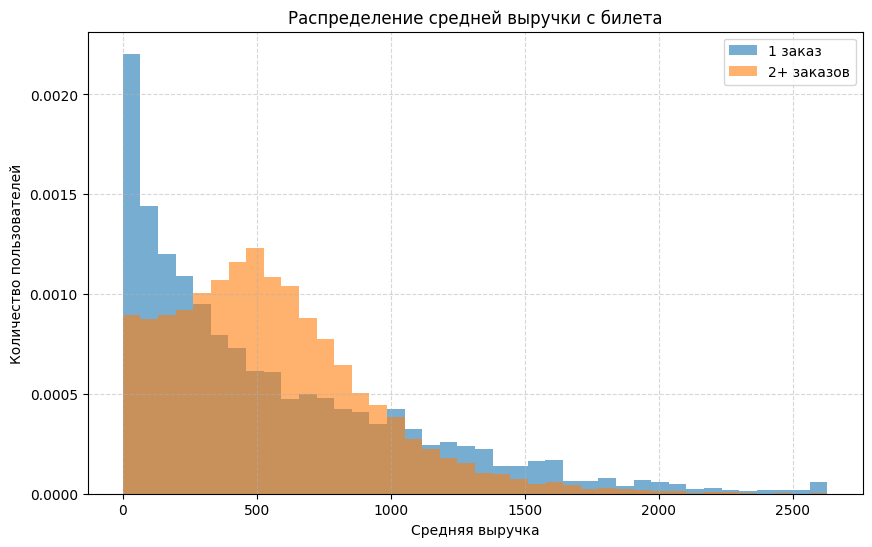

In [56]:
# Построим сравнительную гистограмму распределения средней выручки с билета (avg_revenue_rub)
plt.figure(figsize=(10, 6))

plt.hist(one_order['avg_revenue_rub'], bins=40, alpha=0.6, density=True, label='1 заказ')
plt.hist(two_plus_orders['avg_revenue_rub'], bins=40, alpha=0.6, density=True, label='2+ заказов')

plt.title('Распределение средней выручки с билета')
plt.xlabel('Средняя выручка')
plt.ylabel('Количество пользователей')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

**Выводы по распределению средней выручки с билета**

**1. Средняя выручка у групп почти одинаковая**

Среднее значение практически не отличается между пользователями с 1 заказом и 2+ заказами. Это означает, что по средней выручке сами группы не различаются.

**2. Медианная выручка выше у пользователей с 2+ заказами**

Медиана у пользователей с несколькими заказами заметно выше. Это говорит о том, что типичный возвращающийся пользователь приносит больше выручки, даже если средние значения совпадают.

**3. У однократных пользователей больше разброс значений**

Стандартное отклонение у группы с 1 заказом выше. Это значит, что среди них больше пользователей как с очень низкой, так и с очень высокой выручкой. Их поведение менее предсказуемо.

**4. Однократные пользователи чаще покупают дешёвые билеты**

Нижний квартиль у пользователей с 1 заказом почти в два раза ниже, чем у пользователей с 2+ заказами. Это подтверждает, что они чаще выбирают дешёвые билеты.

**5. У пользователей с 2+ заказами более стабильная структура выручки**

Распределение у группы с повторными заказами более узкое и сосредоточено выше. У них меньше значений в низком диапазоне и более устойчивое поведение, что делает их более ценной группой с точки зрения удержания.

#### 4.2.2. Сравнение распределения по средней выручке с заказа в двух группах пользователей (2-4 и 5+ покупок)

In [57]:
two_to_four_orders['avg_revenue_rub'].describe()

count    7114.000000
mean      557.381026
std       420.088785
min         2.420000
25%       224.062500
50%       477.160000
75%       806.105000
max      2628.420000
Name: avg_revenue_rub, dtype: float64

In [58]:
five_plus_orders['avg_revenue_rub'].describe()

count    6045.000000
mean      544.764352
std       298.206472
min         0.350000
25%       340.440000
50%       521.750000
75%       710.400000
max      2299.870000
Name: avg_revenue_rub, dtype: float64

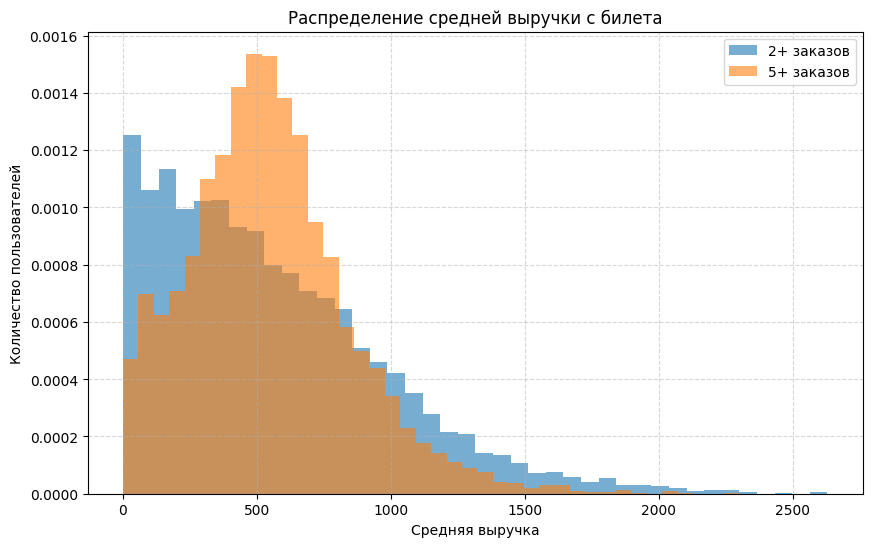

In [59]:
# Построим сравнительную гистограмму распределения средней выручки с билета (avg_revenue_rub)
plt.figure(figsize=(10, 6))

plt.hist(two_to_four_orders['avg_revenue_rub'], bins=40, alpha=0.6, density=True, label='2+ заказов')
plt.hist(five_plus_orders['avg_revenue_rub'], bins=40, alpha=0.6, density=True, label='5+ заказов')

plt.title('Распределение средней выручки с билета')
plt.xlabel('Средняя выручка')
plt.ylabel('Количество пользователей')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

**Выводы по распределению средней выручки (2-4 заказа и 5+ заказов)**

**1. Средняя выручка отличается незначительно**
- 2-4 заказа: **mean ≈ 557**
- 5+ заказов: **mean ≈ 545**

Разница небольшая, но пользователи с 2-4 заказами в среднем тратят **чуть больше**.

**2. Медиана выше у пользователей с 5+ заказами**
- 2-4 заказа: **median ≈ 477**
- 5+ заказов: **median ≈ 522**

Несмотря на более низкое среднее значение, типичный пользователь (по медиане) с 5+ заказами приносит **больше выручки**, чем пользователь с 2-4 заказами.   Это означает более стабильные траты внутри этой группы.

**3. У группы 2-4 заказов гораздо больше разброс**
- Стандартное отклонение у пользователей с 2-4 заказами: **420**
- Стандартное отклонение у пользователей с 5+ заказами: **298**

Группа 2-4 заказов гораздо более неоднородна:
- больше дешёвых покупок,
- больше дорогих покупок,
- длиннее «хвост» справа (много значений 900-1500+).

Группа 5+ заказов более **стабильная**.

**4. Пользователи с 2-4 заказами чаще покупают дешёвые билеты**

25-е перцентили:
- 2-4 заказа: **224**
- 5+ заказов: **340**

Это крупное различие.  
Пользователи 2-4 заказов заметно чаще выбирают дешёвые билеты, что объясняет меньшую медиану и больший разброс.

**5. Пользователи с 2-4 заказами сильнее представлены в дорогих покупках**
- 75-й перцентиль у 2-4 заказов выше (**806** против **710**).
- Хвост распределения у 2-4 заказов тянется практически до **2600**, намного дальше, чем у 5+ заказов.

То есть среди них больше высоких значений, но они не являются "ядром" поведения.

**6. Общий вывод**
**Группа 5+ заказов**:
- более высокая медиана -> более типично высокая выручка,  
- меньше вариативности -> стабильность и предсказуемость,  
- меньше очень дешёвых заказов.

**Группа 2-4 заказов**:
- приносит немного более высокую среднюю выручку за счёт высоких выбросов,
- но медиана заметно ниже,
- поведение гораздо менее стабильное.
 
При похожем среднем чеке пользователи с 5+ заказами выглядят **более стабильной аудиторией**.

#### 4.2.3. Влияние среднего количества билетов в заказе на вероятность повторной покупки

In [60]:
# Изучим распределение пользователей по среднему количеству билетов в заказе
one_order['avg_tickets_count'].describe()

count    8317.000000
mean        2.752074
std         1.149104
min         1.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         6.000000
Name: avg_tickets_count, dtype: float64

In [61]:
two_to_four_orders['avg_tickets_count'].describe()

count    7114.000000
mean        2.740138
std         0.838424
min         1.000000
25%         2.000000
50%         2.670000
75%         3.330000
max         6.000000
Name: avg_tickets_count, dtype: float64

In [62]:
five_plus_orders['avg_tickets_count'].describe()

count    6045.000000
mean        2.731067
std         0.535660
min         1.000000
25%         2.390000
50%         2.710000
75%         3.000000
max         5.400000
Name: avg_tickets_count, dtype: float64

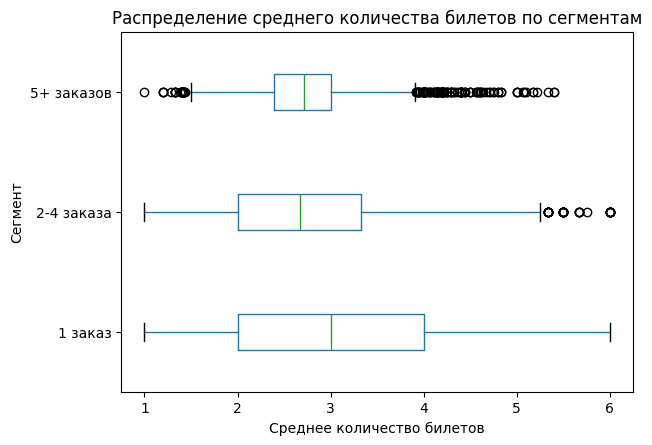

In [63]:
# Построим сравнительную гистограмму распределения количества билетов (avg_tickets_count)
user_profile_copy['order_group'] = pd.cut(
    user_profile_copy['total_orders'],
    bins=[0, 1, 4, float('inf')],
    labels=['1 заказ', '2-4 заказа', '5+ заказов']
)

# Считаем медианы для сортировки
medians = (
    user_profile_copy.groupby('order_group', observed=True)['avg_tickets_count']
    .median()
    .sort_values()
)

df_plot = user_profile_copy[['order_group', 'avg_tickets_count']].copy()

# Строим boxplot
df_plot.boxplot(
    column='avg_tickets_count',
    by='order_group',
    vert=False,
    grid=False
)

plt.title('Распределение среднего количества билетов по сегментам')
plt.suptitle('')
plt.xlabel('Среднее количество билетов')
plt.ylabel('Сегмент')

plt.show()

**Выводы по распределению количества билетов по группам заказов**

**1. Группа "1 заказ"**
- **Самая высокая медиана** среди трёх групп - пользователи с одним заказом чаще покупают больше билетов за раз.
- Широкий межквартильный размах - покупки сильно варьируются.
- Выбросов нет.

**2. Группа "2-4 заказа"**
- Медиана ниже, чем у группы с 1 заказом.
- Межквартильный размах уже - покупки более предсказуемые.
- Небольшое количество выбросов.

**3. Группа "5+ заказов"**
- Медиана самая низкая.
- Диапазон значений самый узкий - наиболее стабильное и одинаковое поведение внутри группы.
- Много мелких выбросов справа.

**Общие выводы**
- **Пользователи с одним заказом покупают больше билетов за одну покупку**, чем те, кто возвращается.
- С увеличением числа заказов количество билетов в среднем снижается и становится более стабильным.
- Группа 5+ orders - самые "предсказуемые" покупатели: небольшие, но регулярные покупки.

In [64]:
# 1. Определяем сегменты
bins = [1, 2, 3, 5, np.inf]
labels = ['1-2 билета', '2-3 билета', '3-5 билетов', '5+ билетов']

user_profile_copy['tickets_segment'] = pd.cut(
    user_profile_copy['avg_tickets_count'],
    bins=bins,
    labels=labels,
    right=False  # интервал включает левую границу, исключает правую
)

# 2. Группировка по сегментам
seg_tickets_count = (
    user_profile_copy.groupby('tickets_segment', observed=True)
    .agg(
        users_total=('user_id', 'count'),
        users_2plus=('is_two', 'sum')
    )
).reset_index()

# 3. Доля повторных заказов
seg_tickets_count['share_2plus'] = seg_tickets_count['users_2plus'] / seg_tickets_count['users_total']

seg_tickets_count = seg_tickets_count.sort_values('share_2plus', ascending=False)

# 4. Красивый вывод
seg_tickets_count.style.format({'share_2plus': '{:.2%}'}).background_gradient(
    subset=['share_2plus'], cmap='YlGnBu'
).set_caption('Сегменты по среднему количеству купленных билетов')

,tickets_segment,users_total,users_2plus,share_2plus
1,2-3 билета,9418,6921,73.49%
2,3-5 билетов,9022,4898,54.29%
0,1-2 билета,2392,1225,51.21%
3,5+ билетов,644,115,17.86%


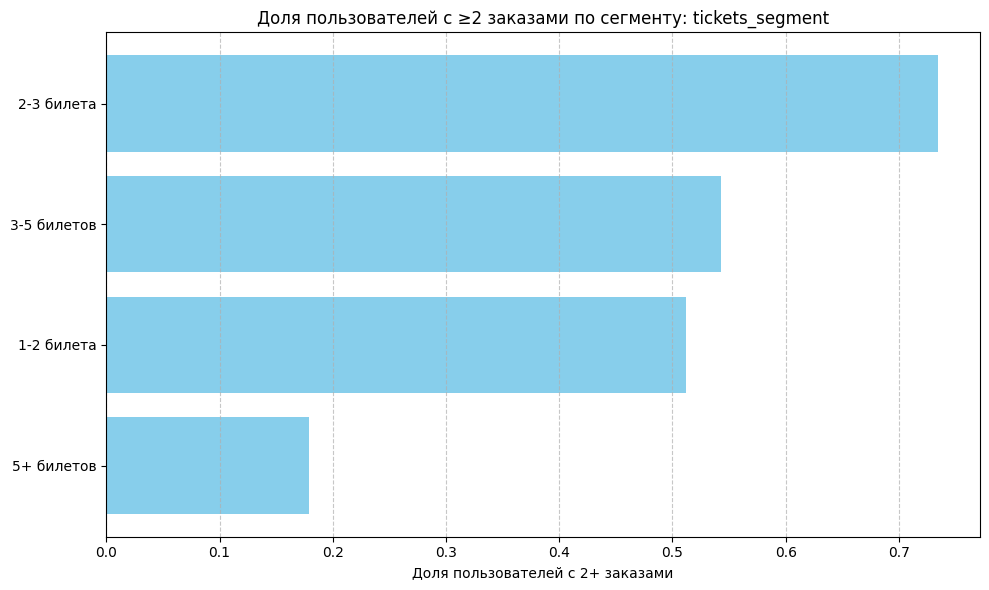

In [65]:
plot_segment_share(seg_tickets_count, 'tickets_segment')

**Выводы по сегментации пользователей по количеству купленных билетов**

**1. Как распределены пользователи по сегментам?**

Распределение **неравномерное** - большинство пользователей сосредоточено в двух средних сегментах:

- **2-3 билета** - 9 627 пользователей  
- **3-5 билетов** - 9 030 пользователей    

Пользователи чаще всего покупают **от 2 до 5 билетов в заказе**.  
Сегменты **1-2 билета** (2 392 пользователя) и **5+ билетов** (644 пользователей) представлены заметно слабее.

**Есть ли сегменты с аномально высокой или низкой долей повторных покупок?**

Да, различия выражены очень ярко:

- **1-2 билета** - 51.21%
- **2-3 билета** - 73.49%
- **3-5 билетов** - 54.29%
- **5+ билетов** - 17.86%

**Аномально высокая доля повторных покупок**
- **Сегмент 2-3 билета** лидирует с большим отрывом. Это самый "лояльный" сегмент.

**Аномально низкая доля повторных покупок**
- **Сегмент 5+ билетов** - всего 17.86%. Это явно нетипичное поведение: большие закупки реже повторяют.

**Общие выводы**
- Пользователи сильно **сконцентрированы в сегментах 2-5 билетов**, а крайние сегменты встречаются редко.
- Самый ценный сегмент - **2-3 билета**, он и многочисленный, и наиболее склонный к повторным заказам.
- Сегмент **5+ билетов** демонстрирует аномально низкую удерживаемость.

---

### 4.3. Исследование временных характеристик первого заказа и их влияния на повторные покупки

Изучим временные параметры, связанные с первым заказом пользователя.

Время с момента первой покупки - Лайфтайм:

In [66]:
user_profile_copy['lifetime_days'] = (
    user_profile_copy['last_order_dt'] - user_profile_copy['first_order_dt']
).dt.days

lifetime_stats = user_profile_copy['lifetime_days'].describe()
lifetime_stats

count    21476.000000
mean        38.149423
std         51.546411
min          0.000000
25%          0.000000
50%          0.000000
75%         78.000000
max        152.000000
Name: lifetime_days, dtype: float64

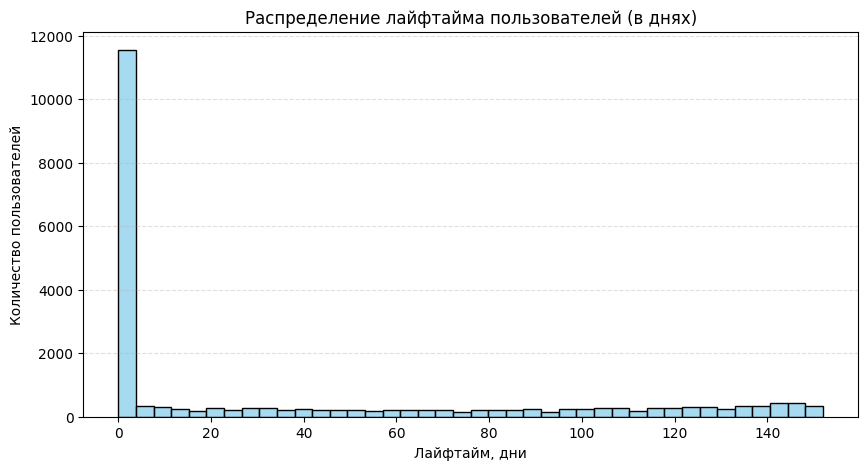

In [67]:
plt.figure(figsize=(10, 5))
sns.histplot(user_profile_copy['lifetime_days'], bins=40, color='skyblue')
plt.title('Распределение лайфтайма пользователей (в днях)')
plt.xlabel('Лайфтайм, дни')
plt.ylabel('Количество пользователей')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

In [68]:
users_lifecycle_gt_1d = user_profile_copy[user_profile_copy['lifetime_days'] > 0]

lifecycle_gt_1d = users_lifecycle_gt_1d['user_id'].count() / user_profile_copy['user_id'].count()
print(f'Доля пользователей, разница между первым и последним заказом которых составляет более одного дня: {lifecycle_gt_1d:.2%}')

Доля пользователей, разница между первым и последним заказом которых составляет более одного дня: 48.61%


Медиана лайфтайма пользователей равна 0, что говорит о том, что у большого числа клиентов первый и последний заказы приходятся на один и тот же день. Доля пользователей, у которых разница между первым и последним заказом превышает один день, составляет всего 48.61%. Вероятно, это связано с тем, что многие покупают билеты на несколько мероприятий одновременно, разделяя покупки на несколько заказов. С точки зрения маркетинга такие клиенты не должны считаться повторными.
Поэтому пересчитаем метрики, исключив пользователей, у которых первый и последний заказы произошли в один день.

In [69]:
users_lifecycle_gt_1d['lifetime_days'].describe()

count    10440.000000
mean        78.476724
std         47.968338
min          1.000000
25%         34.000000
50%         81.000000
75%        123.000000
max        152.000000
Name: lifetime_days, dtype: float64

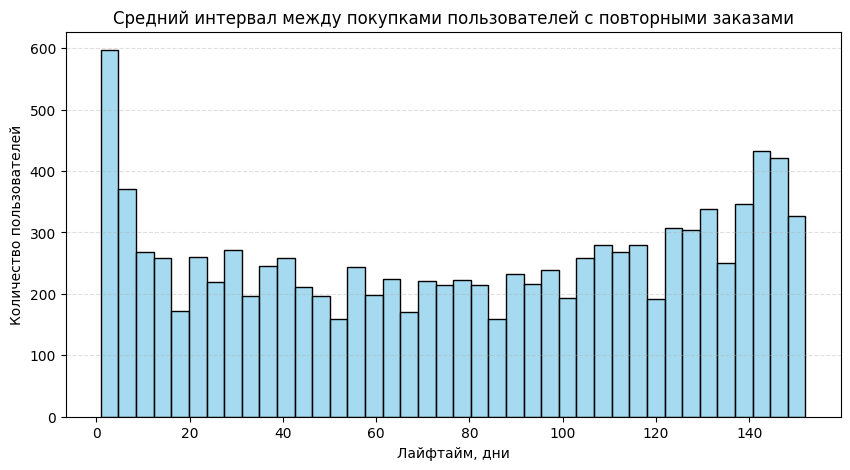

In [70]:
plt.figure(figsize=(10, 5))
sns.histplot(users_lifecycle_gt_1d['lifetime_days'], bins=40, color='skyblue')
plt.title('Средний интервал между покупками пользователей с повторными заказами')
plt.xlabel('Лайфтайм, дни')
plt.ylabel('Количество пользователей')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

**Повторные покупатели (lifetime_days > 0)**

- **Количество пользователей: 10 440.**  
  Это примерно половина всей базы.

- **Медиана лайфтайма = 81 день.**  
  То есть половина «возвращающихся» клиентов делает как минимум две покупки, растянутые почти на 3 месяца.

- **Среднее = 78.47 дня, стандартное отклонение = 47.96.**  
  Большой разброс: одни делают повторный заказ через несколько недель, другие - через несколько месяцев.

- Гистограмма для пользователей с повторными покупками имеет заметную **вогнутую форму**: значения в середине интервала (10-120 дней) находятся ниже, чем пики по краям. Это создаёт эффект «провала» в центре распределения.

    Такой вид характерен для **двухмодального поведения** пользователей:

    1. **Часть пользователей делает повторный заказ довольно быстро** - в течение первых 5-10 дней.  
   Это создаёт первый пик слева.

    2. **Другая часть - наоборот, возвращается очень поздно**, через 140+ дней.  
   Это формирует второй подъём справа.


**Общие выводы**
- Удерживаемые пользователи действительно "живут" долго - типичный цикл больше месяца.
- Основная проблема не в удержании тех, кто вернулся хотя бы раз, а в том, что **половина пользователей никогда не делает второй заказ**.
- Анализ удержания стоит фокусировать именно на группе повторных покупателей (lifetime > 0), чтобы видеть адекватные интервалы между покупками.

---

#### 4.3.1. Анализ влияния дня недели, в который была совершена первая покупка, на поведение пользователей

In [71]:
# Преобразуем дату первой покупки в день недели
user_profile_copy['first_order_weekday'] = user_profile_copy['first_order_dt'].dt.day_name()

# Задаем порядок дней недели
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

In [72]:
orders_by_weekday = (
    user_profile_copy['first_order_weekday']
    .value_counts()
    .rename_axis('weekday')
    .reset_index(name='users_count')
)

orders_by_weekday['weekday'] = pd.Categorical(
    orders_by_weekday['weekday'],
    categories=weekday_order,
    ordered=True
)

orders_by_weekday = orders_by_weekday.sort_values('weekday')

orders_by_weekday['users_share'] = orders_by_weekday['users_count'] / len(user_profile)

orders_by_weekday.style.format({'users_share': '{:.2%}'}).background_gradient(
    subset=['users_share'], cmap='YlGnBu'
).set_caption('Распределение пользователей по дню недели первой покупки')

,weekday,users_count,users_share
5,Monday,2900,13.37%
2,Tuesday,3159,14.56%
4,Wednesday,3048,14.05%
3,Thursday,3097,14.28%
1,Friday,3229,14.88%
0,Saturday,3288,15.16%
6,Sunday,2755,12.70%


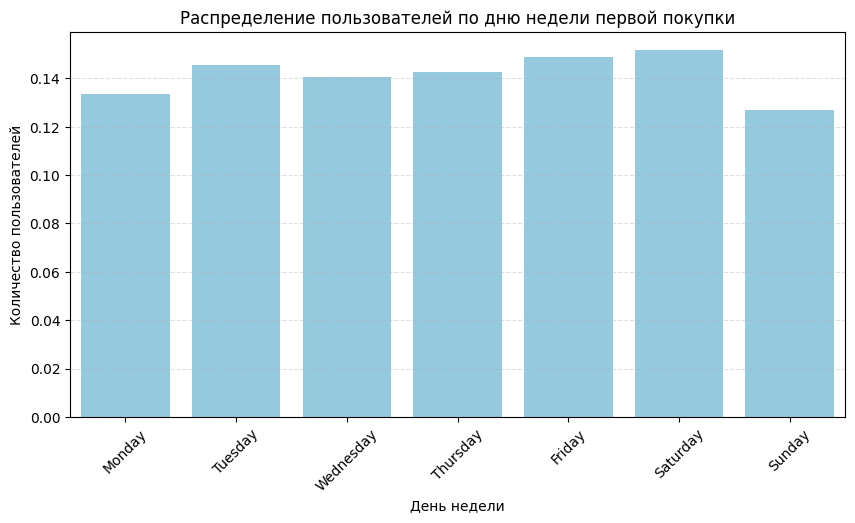

In [73]:
plt.figure(figsize=(10, 5))
sns.barplot(data=orders_by_weekday, x='weekday', y='users_share', color='skyblue')
plt.title('Распределение пользователей по дню недели первой покупки')
plt.xticks(rotation=45)
plt.xlabel('День недели')
plt.ylabel('Количество пользователей')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

**1. Пользователи довольно равномерно распределены по дням недели**  
Разница между днями недели минимальная: доли колеблются примерно от **12.8% до 15.3%**.  
Это означает, что **первую покупку совершают более-менее ровно в любой день недели**, без выраженного пика.

**2. Наибольшее количество первых покупок делают в выходные**  
- **Saturday - 15.31%**  
- **Friday - 15.04%**

Это может указывать на то, что пользователи активнее совершают первую покупку в свободные дни.

**3. Самый “слабый” день - воскресенье**  
- **Sunday - 12.83%**

Возможно, в этот день ниже общая активность.

**Общий итог**  
- **Распределение почти ровное** - нет резких провалов и всплесков.  
- **Пятница и суббота - самые популярные дни первого заказа.**  
- **Воскресенье - самый тихий день.**

Такая структура говорит о том, что маркетинговые кампании, направленные на привлечение новых пользователей, **могут работать одинаково эффективно в любой день недели**, а не только в определённые периоды.

In [74]:
# Шаг 2. Группируем по дню недели
weekday_stats = (
    user_profile_copy
    .groupby('first_order_weekday')
    .agg(
        total_users=('user_id', 'count'),
        two_plus_share=('is_two', 'mean')
    )
    .reset_index()
)

In [75]:
# Шаг 3. Сортируем дни недели по порядку
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

weekday_stats['first_order_weekday'] = pd.Categorical(
    weekday_stats['first_order_weekday'],
    categories=weekday_order,
    ordered=True
)

weekday_stats = weekday_stats.sort_values('first_order_weekday')

weekday_stats.style.format({'two_plus_share': '{:.2%}'}).background_gradient(
    subset=['two_plus_share'], cmap='YlGnBu'
).set_caption('Доля пользователей, совершивших более одного заказа, по дню первой покупки')

,first_order_weekday,total_users,two_plus_share
1,Monday,2900,62.62%
5,Tuesday,3159,61.70%
6,Wednesday,3048,62.14%
4,Thursday,3097,59.51%
0,Friday,3229,59.89%
2,Saturday,3288,62.80%
3,Sunday,2755,60.18%


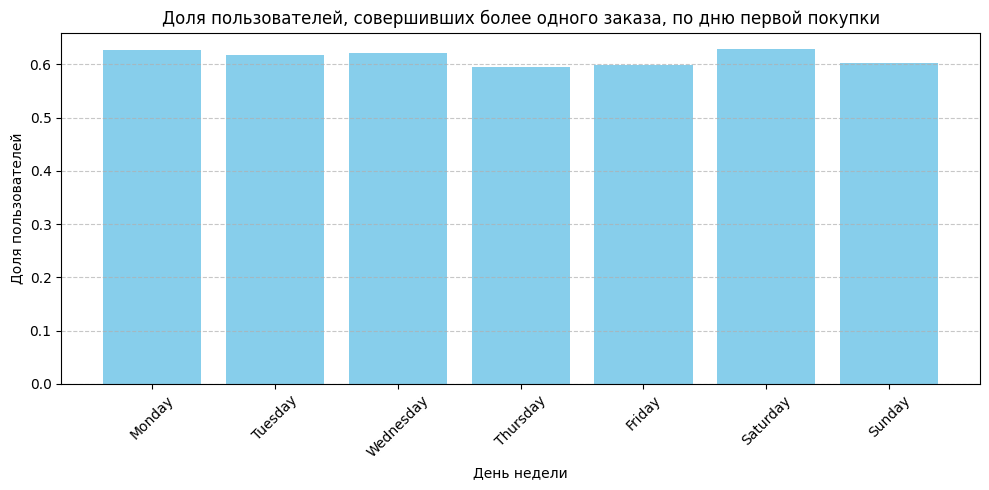

In [76]:
plt.figure(figsize=(10, 5))
plt.bar(
    weekday_stats['first_order_weekday'],
    weekday_stats['two_plus_share'],
    color='skyblue'
)

plt.title('Доля пользователей, совершивших более одного заказа, по дню первой покупки')
plt.xlabel('День недели')
plt.ylabel('Доля пользователей')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Доля повторных покупателей довольно стабильна по всей неделе**  
Показатели колеблются в узком диапазоне от **59.5% до 62.8%**, что говорит о том, что **день первой покупки почти не влияет на вероятность сделать повторный заказ**.

**1. Наиболее "лояльные" дни - понедельник, среда и суббота**
- **Monday - 62.62%**
- **Wednesday - 62.14%**
- **Saturday - 62.80% (самый высокий показатель)**

Пользователи, начавшие знакомство с сервисом в эти дни, немного чаще возвращаются.

**2. Наименьшая доля повторных заказов - четверг**
- **Thursday - 59.51%**

Разница небольшая, но заметная: четверг выделяется как день с чуть более низкой повторной активностью.

**3. В пятницу и воскресенье показатели средние**
- **Friday - 59.89%**
- **Sunday - 60.18%**

Это нормальный уровень удержания, без отклонений.

**Общий итог**
- **Существенных различий между днями нет.**  
- Вероятность сделать второй заказ слабо зависит от того, в какой день был первый.  
- Суббота, понедельник и среда - небольшие локальные пики, но разница слишком мала, чтобы делать серьёзные выводы.

Таким образом, **день первой покупки не является значимым фактором удержания**.

#### 4.3.2. Влияние среднего интервала между заказами на удержание клиентов

Среднее время между заказами для двух групп пользователей:

In [77]:
labels = ['2-4 заказа', '5+ заказов']

In [78]:
stats = pd.DataFrame({
    'group': labels,
    'count_users': [len(two_to_four_orders), len(five_plus_orders)],
    'mean_days_between': [two_to_four_orders['avg_days_between'].mean(),
                          five_plus_orders['avg_days_between'].mean()],
    'median_days_between': [two_to_four_orders['avg_days_between'].median(),
                            five_plus_orders['avg_days_between'].median()],
    'std_days_between': [two_to_four_orders['avg_days_between'].std(),
                         five_plus_orders['avg_days_between'].std()]
})

stats

,group,count_users,mean_days_between,median_days_between,std_days_between
0,2-4 заказа,7114,21.218520,9.00,28.351610
1,5+ заказов,6045,9.887952,8.11,7.786686


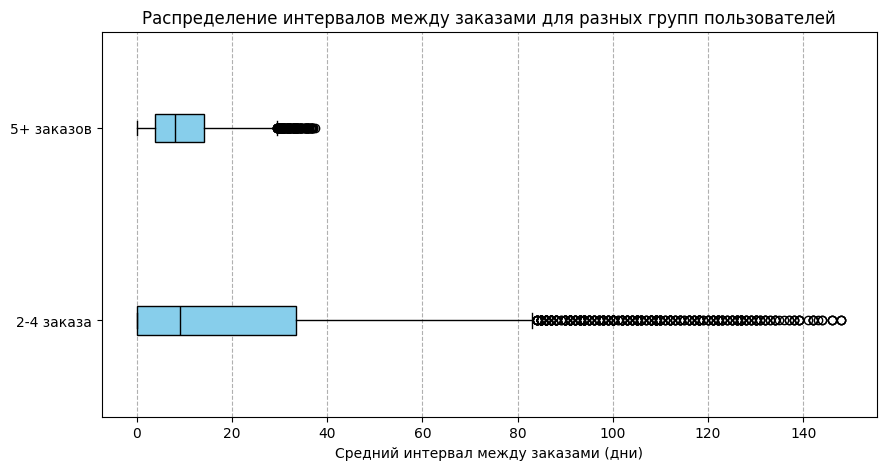

In [79]:
plt.figure(figsize=(10, 5))

data = [
    two_to_four_orders['avg_days_between'],
    five_plus_orders['avg_days_between']
]

plt.boxplot(
    data,
    vert=False,
    tick_labels=labels,
    patch_artist=True,
    boxprops=dict(facecolor='skyblue'),
    medianprops=dict(color='black')
)

plt.xlabel('Средний интервал между заказами (дни)')
plt.title('Распределение интервалов между заказами для разных групп пользователей')
plt.grid(axis='x', linestyle='--')

plt.show()

**Сравнение групп по распределению интервалов**
Boxplot показывает **резкое различие** между двумя сегментами:

**Группа 2-4 заказа**
- Имеет **очень длинный "хвост" вправо** - множество пользователей совершают повторный заказ через **60 дней** и более.
- IQR (межквартильный размах) широкий: пользователи очень неоднородны.
- **Медиана ≈ 9 дней**, но это значение не отражает реальной картины, потому что:
  - распределение **сильно скошено** вправо
  - много выбросов
- Большое стандартное отклонение (≈28.35 дней) подтверждает **высокую вариативность**.

**Вывод:** в этой группе смешиваются разные поведенческие типы - от регулярных покупателей до тех, кто приходит раз в несколько месяцев.

**Группа 5+ заказов**
- Boxplot гораздо "компактнее".
- Медиана **около 8 дней** и она хорошо описывает распределение, т.к. нет сильных выбросов.
- IQR узкий: большинство пользователей совершают повторные покупки в **интервале примерно 5-12 дней**.
- Стандартное отклонение маленькое (≈7.79), что подтверждает **стабильность поведения**.

**Вывод:** это группа лояльных, регулярно покупающих клиентов с почти одинаковой частотой покупок.

**Общий вывод:**

- **5+ заказов** - стабильный, повторяемый паттерн поведения (узкий boxplot, мало выбросов).  
- **2-4 заказа** - огромный разброс интервалов, много выбросов, медиана не отражает реальность.


In [80]:
# Исключим из анализа клиентов, чьи первый и последний заказы пришлись на один день
two_to_four_orders_filtered = two_to_four_orders[
    (two_to_four_orders['last_order_dt'] - two_to_four_orders['first_order_dt']).dt.days > 0
]

five_plus_orders_filtered = five_plus_orders[
    (five_plus_orders['last_order_dt'] - five_plus_orders['first_order_dt']).dt.days > 0
]

stats_filtered = pd.DataFrame({
    'group': labels,
    'count_users': [len(two_to_four_orders_filtered), len(five_plus_orders_filtered)],
    'mean_days_between': [two_to_four_orders_filtered['avg_days_between'].mean(),
                          five_plus_orders_filtered['avg_days_between'].mean()],
    'median_days_between': [two_to_four_orders_filtered['avg_days_between'].median(),
                            five_plus_orders_filtered['avg_days_between'].median()],
    'std_days_between': [two_to_four_orders_filtered['avg_days_between'].std(),
                         five_plus_orders_filtered['avg_days_between'].std()]
})

stats

,group,count_users,mean_days_between,median_days_between,std_days_between
0,2-4 заказа,7114,21.218520,9.00,28.351610
1,5+ заказов,6045,9.887952,8.11,7.786686


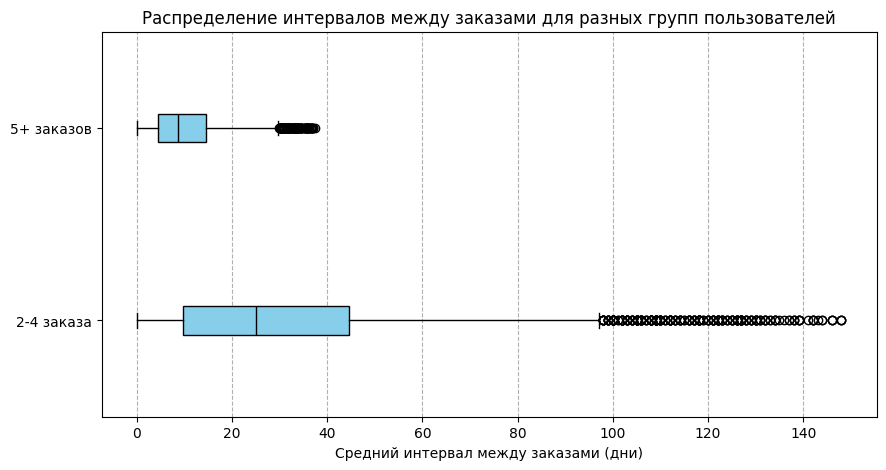

In [81]:
plt.figure(figsize=(10, 5))

data = [
    two_to_four_orders_filtered['avg_days_between'],
    five_plus_orders_filtered['avg_days_between']
]

plt.boxplot(
    data,
    vert=False,
    tick_labels=labels,
    patch_artist=True,
    boxprops=dict(facecolor='skyblue'),
    medianprops=dict(color='black')
)

plt.xlabel('Средний интервал между заказами (дни)')
plt.title('Распределение интервалов между заказами для разных групп пользователей')
plt.grid(axis='x', linestyle='--')

plt.show()

После фильтрации распределение стало чище, и различия между группами стали ещё заметнее.

**Сравнение групп по статистикам**

**Группа 2-4 заказа**
- **Медиана: 9 дней**
- **Среднее: 21.22 дня**
- **Стандартное отклонение: 28.35 дней**

Это по-прежнему очень вариативная группа:
- Среднее сильно больше медианы -> **распределение скошено вправо**.
- Очень большой размах значений - видно по длинному хвосту боксплота.
- Пользователи крайне неоднородны: часть делает повторный заказ через 5-10 дней, а часть — через 60 и больше.

**Группа 5+ заказов**
- **Медиана: 8.11 дня**
- **Среднее: 9.88 дня**
- **Стандартное отклонение: 7.79 дня**

Заметно более стабильная группа:
- Среднее ≈ медиане -> распределение симметричнее.
- Узкий IQR.
- Не так много выбросов.
- Поведение пользователей однороднее.

**Основные выводы**

**1. Даже после исключения однодневных пользователей:**
- **2-4 заказа** -> крайне неоднородная группа.
- **5+ заказов** -> стабильное регулярное поведение.

**2. Проблема группы 2-4 - сильная вариативность**
Это группа, где смешаны:
- пользователи, у которых повторный заказ через неделю;
- пользователи, делающие повтор через 2-4 месяца;
- редкие разовые повторы, не указывающие на реальную вовлечённость.

**3. Группа 5+ - "ядро" лояльной аудитории**
- Повторные покупки происходят предсказуемо.
- Высокая частота - около 1 недели.
- Почти нет критически больших выбросов.

**4. Стандартное отклонение подчёркивает разницу**
- 28.35 дней в группе 2-4 - огромная вариативность.
- 7.79 дней в группе 5+ - пользователей можно рассматривать как одну поведенческую когорту.
  
---

Корреляцию между интервалом и вероятностью повторного заказа посчитаем сразу только по тем клиентам, чьи первые и последние заказы не приходились на один день.

In [82]:
correlation = users_lifecycle_gt_1d['avg_days_between'].corr(users_lifecycle_gt_1d['total_orders'])

print(f"Коэффициент корреляции (avg_interval_days vs total_orders): {correlation:.4f}")

Коэффициент корреляции (avg_interval_days vs total_orders): -0.3148


**Вывод на основе коэффициента корреляции:** коэффициент корреляции составляет -0.3148, существует умеренная отрицательная связь.

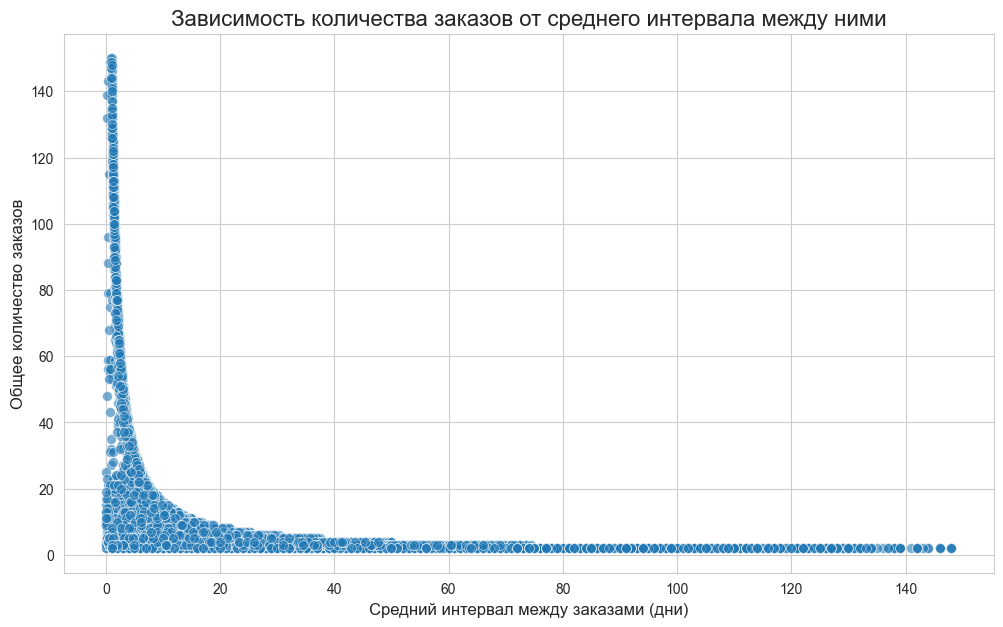

In [83]:
sns.set_style("whitegrid")

plt.figure(figsize=(12, 7))

sns.scatterplot(
    x='avg_days_between',
    y='total_orders',
    data=users_lifecycle_gt_1d,
    alpha=0.6,
    s=50
)

plt.title('Зависимость количества заказов от среднего интервала между ними', fontsize=16)
plt.xlabel('Средний интервал между заказами (дни)', fontsize=12)
plt.ylabel('Общее количество заказов', fontsize=12)

plt.show()

**Интерпретация Диаграммы Рассеяния**
1. Общая форма: сильная отрицательная нелинейная связь  
Связь между переменными строго отрицательная. По мере увеличения среднего интервала общее количество заказов резко и почти полностью падает.

2. Анализ ядра данных (область 0-10 дней)  
Самая плотная и важная область графика - это интервал от 0 до 10 дней. В этой области находится абсолютное большинство клиентов с высокой лояльностью (те, кто сделал более 20-30 заказов). Пользователи с 140+ заказами полностью сосредоточены в этой зоне.  
**Вывод:** Ключевой фактор лояльности - это скорость возвращения. Клиенты, которые быстро делают повторные покупки (в среднем, менее чем через 10 дней), - это те, кто с большей вероятностью станет самыми ценными и многократно покупающими клиентами.

3. Анализ области "Средний интервал" (область 10-40 дней)  
Количество заказов резко падает до уровня менее 20.  
**Вывод:** Если клиент в среднем возвращается реже, чем раз в 10-15 дней, его потенциал для совершения большого количества покупок (свыше 20) стремительно падает. Средний интервал свыше 30 дней (раз в месяц) практически гарантирует, что клиент сделает всего несколько заказов.

4. Анализ "Длинного хвоста" (область свыше 40 дней)  
После 40 дней (и до 140+ дней) все точки лежат очень низко, почти прижимаясь к оси X.  
**Вывод:** Клиенты, которые совершают покупки со средним интервалом более 40 дней, практически всегда являются единичными (повторными) покупателями (2-4 заказа). Длинный интервал почти исключает высокую лояльность.

---

### 4.4. Корреляционный анализ количества покупок и признаков пользователя

In [84]:
user_profile_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21476 entries, 0 to 21692
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   user_id              21476 non-null  object        
 1   first_order_dt       21476 non-null  datetime64[ns]
 2   last_order_dt        21476 non-null  datetime64[ns]
 3   first_device         21476 non-null  object        
 4   first_region         21476 non-null  object        
 5   first_service        21476 non-null  object        
 6   first_event_type     21476 non-null  object        
 7   total_orders         21476 non-null  int64         
 8   avg_revenue_rub      21476 non-null  float64       
 9   avg_tickets_count    21476 non-null  float64       
 10  avg_days_between     13229 non-null  Float64       
 11  is_two               21476 non-null  int64         
 12  is_five              21476 non-null  int64         
 13  order_group          21476 non-null 

In [85]:
# Вычисляем корреляционную матрицу с использованием phi_k
# Список колонок в анализе
cols = [
    'first_order_dt', 'first_device', 'first_region', 'first_service', 'first_event_type',
    'total_orders', 'avg_revenue_rub', 'avg_tickets_count', 'avg_days_between', 'first_order_weekday'
]

# Типы колонок
interval_cols = [
    'total_orders',
    'avg_revenue_rub',
    'avg_tickets_count',
    'avg_days_between'
]

correlation_matrix = user_profile_copy[cols].phik_matrix(interval_cols=interval_cols)

print("Корреляционная матрица с коэффициентом phi_k для переменной total_orders:")
correlation_matrix.loc[correlation_matrix.index != 'total_orders'][['total_orders']]\
    .sort_values(by='total_orders', ascending=False)

Корреляционная матрица с коэффициентом phi_k для переменной total_orders:


,total_orders
first_order_dt,0.421454
avg_tickets_count,0.342366
avg_days_between,0.295125
avg_revenue_rub,0.225937
first_region,0.121402
first_order_weekday,0.052319
first_service,0.035876
first_event_type,0.027655
first_device,0.009005


**Общий вывод по текущей корреляции**

По полученной матрице уже можно видеть достаточно хорошую корреляцию с некоторыми признаками, но т.к. мы знаем, что у нас в таблице значительное количество пользователей совершило всего по одному заказу, попробуем еще чуть-чуть улучшить модель, посчитав корреляцию с ранее выделенным столбцом `order_group`, где пользователи были разбиты на более равномерные группы по количеству заказов.

In [86]:
# Проверка распределения столбца group, созданного ранее для сегментации пользователей
print("\nРаспределение нового сегмента лояльности:")
print(user_profile_copy['order_group'].value_counts(normalize=True))


Распределение нового сегмента лояльности:
order_group
1 заказ       0.387270
2-4 заказа    0.331253
5+ заказов    0.281477
Name: proportion, dtype: float64


In [87]:
# Новый список колонок для анализа
cols_segmented = [
    'first_order_dt', 'first_device', 'first_region', 'first_service', 'first_event_type',
    'order_group', 'avg_revenue_rub', 'avg_tickets_count', 'avg_days_between', 'first_order_weekday'
]

# Пересчитываем матрицу Phik
correlation_matrix_segmented = user_profile_copy[cols_segmented].phik_matrix(interval_cols=interval_cols)

# Вывод результатов для новой целевой переменной
print("\nКорреляционная матрица с коэффициентом phi_k для переменной group:")
correlation_matrix_segmented.loc[correlation_matrix_segmented.index != 'order_group'][['order_group']]\
    .sort_values(by='order_group', ascending=False)


Корреляционная матрица с коэффициентом phi_k для переменной group:


,order_group
avg_tickets_count,0.584417
first_order_dt,0.575707
avg_days_between,0.397583
avg_revenue_rub,0.326070
first_region,0.128872
first_service,0.082471
first_event_type,0.042093
first_order_weekday,0.030413
first_device,0.017711


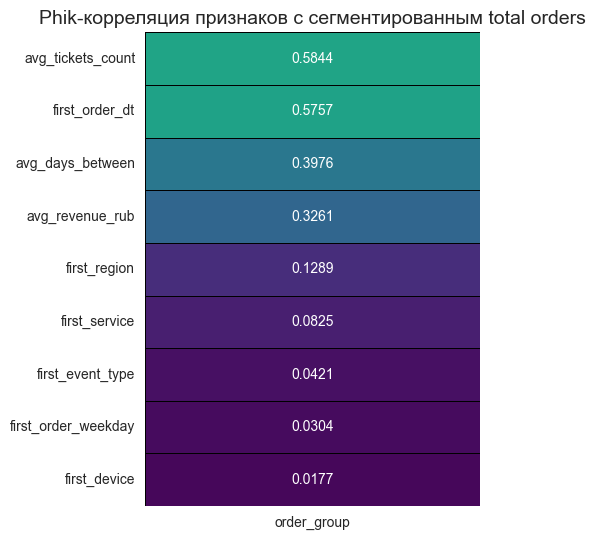

In [88]:
orders_corr = (
    correlation_matrix_segmented[['order_group']]
    .drop('order_group', axis=0)
    .sort_values(by='order_group', ascending=False)  # сортировка по убыванию
)

# 2. Настройка графика
plt.figure(figsize=(5, len(orders_corr) * 0.5 + 1))

# 3. Тепловая карта (вертикальная)
sns.heatmap(
    orders_corr,
    annot=True,
    fmt=".4f",
    cmap='viridis',
    cbar=False,
    linewidths=.5,
    linecolor='black',
    vmin=0, vmax=1
)

plt.title('Phik-корреляция признаков с сегментированным total orders', fontsize=14)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Результаты анализа**

**1. avg_tickets_count (ϕk = 0.5844, очень сильная связь)**
- Среднее количество билетов в одном заказе сильно связано с лояльностью.
- Клиенты, которые покупают больше билетов за один заказ, чаще попадают в более лояльные сегменты.
- Этот признак является ключевым для построения модели сегментации и анализа поведения клиентов.

**2. first_order_dt (ϕk = 0.5757, очень сильная связь)**
- Дата первого заказа сильно влияет на сегмент лояльности.
- Вероятно, чем раньше клиент совершил первый заказ, тем больше вероятность того, что у него будет время совершить повторную покупку.
- Этот признак может быть использован как один из основных факторов для прогнозирования лояльности клиентов.

**3. avg_days_between (ϕk = 0.3976, умеренно сильная связь)**
- Средний интервал между заказами показывает умеренную связь с лояльностью.
- Меньший интервал между заказами обычно указывает на более высокую активность и лояльность клиента.
- Может использоваться в комбинации с другими признаками для улучшения точности моделей.

**4. avg_revenue_rub (ϕk = 0.3261, умеренная связь)**
- Средний доход от клиента имеет умеренное влияние на сегмент лояльности.
- Более высокие траты могут указывать на более лояльного клиента, но связь не такая сильная, как у среднего количества билетов или времени первого заказа.
- Можно учитывать в модели, но в приоритетном порядке ниже первых двух признаков.

**5. first_region (ϕk = 0.1289, слабая связь)**
- Регион, в котором клиент совершил первый заказ, имеет слабую связь с лояльностью клиентов.
- Значение региона полезно для анализа, но в модели сегментации не является ключевым фактором.

**6. first_service (ϕk = 0.0825, очень слабая связь)**
- Тип первой услуги почти не влияет на сегмент лояльности.

**7. first_event_type (ϕk = 0.0421, отсутствие связи)**
- Тип первого события не связан с лояльностью.

**8. first_order_weekday (ϕk = 0.0304, отсутствие связи)**
- День недели первой покупки практически не влияет на сегмент лояльности.

**9. first_device (ϕk = 0.0177, отсутствие связи)**
- Используемое устройство при первом заказе практически не влияет на сегмент лояльности.

**Общие выводы**
1. **Главные предикторы лояльности:**
   - `first_order_dt` и `avg_tickets_count` - наиболее сильные и информативные признаки.
2. **Средние по значимости признаки:**
   - `avg_days_between` и `avg_revenue_rub` могут усилить модель, но их влияние умеренное.
3. **Признаки с низкой и отсутствующей значимостью:**
   - `first_region`, `first_service`, `first_event_type`, `first_order_weekday`, `first_device` незначительно влияют на сегментацию.
  
---

## 5. Общие выводы и рекомендации

#### Итоговый вывод по данным и их подготовке

Данные представляют собой таблицу с 15 столбцами и 290 611 строками о покупке билетов на мероприятия. Столбцы содержат числовые, текстовые значения и даты (`object`, `int64`, `datetime64`, `float64`). Пропуски есть только в столбце `days_since_prev`, что соответствует первой покупке пользователя.  

В процессе предобработки были выполнены следующие шаги:  
- Преобразование `days_since_prev` к типу `Int64` для корректного хранения пропусков.  
- Оптимизация столбца `tickets_count` с уменьшением разрядности.  
- Приведение выручки (`revenue`) к единой валюте (рубли) из-за наличия данных в рублях и тенге.  
- Исключение выбросов по 99-му перцентилю для `revenue` и `tickets_count`, а также отрицательных и нулевых значений для `revenue`.  

После обработки объём данных составил 281 705 строк (удалено 8 906 строк, 3,05%), что является небольшой потерей и не влияет на качество анализа. Данные имеют хороший уровень качества, достаточный объём для анализа, и готовы к дальнейшему использованию для изучения лояльности клиентов.

#### Основные результаты анализа. 
**Итоговый вывод по пользователям и активности**

- **Общее число пользователей:** 21 476. Выборка достаточна для устойчивых выводов.  
- **Число заказов:** медиана - 2, 75-й перцентиль - 5, после удаления аномальных максимумов среднее число заказов стало 6.4, максимум - 150.  
- **Среднее количество билетов на один заказ:** среднее 2.74, максимум 6, распределение равномерное.  
- **Интервалы между заказами:** медиана 8 дней, среднее 15.9 дней, максимальный интервал 148 дней.  
- **Выручка:** средняя выручка с одного заказа 528.64 руб.  
- **Доля активных пользователей:** 61.66 % сделали ≥2 заказа, 28.87 % - ≥5 заказов.  

После фильтрации экстремальных значений данные корректно отражают поведение большинства пользователей и готовы для анализа активности и лояльности.

#### Итоговый вывод по признакам первого заказа

Анализ показал, что ключевым признаком первого заказа, влияющим на возврат пользователей, является `дата первого заказа`.

Дата первого заказа оказывает очень сильное влияние: чем раньше клиент совершил первый заказ, тем выше вероятность его повторного возвращения. 

#### Связь средней выручки и количества билетов с вероятностью повторных покупок

Анализ показал, что **среднее количество билетов в заказе** сильно связано с вероятностью повторных покупок: клиенты, приобретающие больше билетов за один заказ, чаще возвращаются. **Средняя выручка с одного заказа** имеет умеренное влияние на возврат пользователей: более высокие траты могут быть связаны с большей лояльностью, но связь менее выражена, чем у числа билетов. Таким образом, количество билетов является более сильным предиктором повторных покупок, чем сумма заказа.

#### Влияние временных характеристик на удержание пользователей

Анализ показал, что **день недели первого заказа** практически не влияет на вероятность повторных покупок, тогда как **средний интервал между покупками** (`avg_days_between`) имеет умеренное влияние. Клиенты с меньшими интервалами между заказами проявляют более высокую активность и чаще возвращаются, поэтому именно регулярность покупок является важным фактором удержания.

#### Общий вывод о корреляции
Главными характеристиками первого заказа и профиля пользователя, влияющими на число покупок являются: `дата первого заказа`, `среднее количество билетов в заказе`, `среднее количество дней между заказами` и `средняя выручка с заказа`.

Среднее количество билетов в одном заказе сильно связано с лояльностью - клиенты, покупающие больше билетов за один раз, чаще возвращаются. Средний интервал между заказами показывает умеренную связь: меньшие интервалы между покупками указывают на более высокую активность и повышают вероятность повторных заказов. Эти признаки являются основными факторами для прогнозирования лояльности клиентов. Средний доход от клиента имеет умеренное влияние на сегмент лояльности: более высокие траты могут указывать на более лояльного клиента.

#### Важное наблюдение
Стоит обратить внимание на тот факт, что более 50% пользователей с 2+ заказами совершали свою последнюю покупку в тот же день, что и первую, что говорит о том, что таких клиентов скорее всего нельзя назвать повторными. 

## Рекомендации для заказчика

Анализ показал, что наиболее стабильными и предсказуемыми являются пользователи с **5+ заказами**. Хотя их средняя сумма заказа может быть чуть ниже, у них меньше очень дешёвых покупок, и они чаще возвращаются. 

С учётом того, что старые пользователи чаще делают повторные покупки, **рекомендуется сконцентрировать усилия на удержании существующих клиентов**, особенно на лояльной группе с 5+ заказами. Для новых или менее активных пользователей можно применять дополнительные маркетинговые активности, но основной фокус стоит сделать на поддержке и вовлечении уже лояльных клиентов.